# **Clasificación de Clientes en Mora mediante Redes Neuronales Artificiales**
***S. Bustamante - Tabares***

***1001419952***



## **Fase 1 — Limpieza y Preparación de Datos**

---

> **Problema:** Clasificación binaria para predecir si un cliente presentará mora (3 a 30 días de atraso) a partir de variables financieras y demográficas.  
> **Variable objetivo:** `M3_30AC` — `1` indica mora, `0` sin mora.  


1.1 Instalación e importación de librerías

1.2 Carga de datos

1.3 Inspección inicial

1.4 Tratamiento de valores nulos

1.5 Tratamiento de duplicados

1.6 Análisis y tratamiento de outliers

1.7 Codificación de variables categóricas

1.8 Tratamiento del desbalance de clases (undersampling)

1.9 Escalado de variables numéricas

1.10 Exportación del dataset limpio

---

---
### 1.1 Instalación e importación de librerías

In [1]:
!pip install imbalanced-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Paleta de colores — fondo crema / beige claro
BG_MAIN   = '#FAF7F2'
BG_AXES   = '#F2EDE4'
BG_SAVE   = '#FAF7F2'

COLOR_POS  = '#6C4EE0'
COLOR_NEG  = '#00A882'
COLOR_WARN = '#D94F4F'
COLOR_ACC  = '#E08C00'
COLOR_TEXT = '#2D2D2D'
COLOR_GRID = '#D8D0C6'

plt.rcParams.update({
    'figure.facecolor' : BG_MAIN,
    'axes.facecolor'   : BG_AXES,
    'axes.edgecolor'   : '#C8BFB0',
    'axes.labelcolor'  : COLOR_TEXT,
    'xtick.color'      : COLOR_TEXT,
    'ytick.color'      : COLOR_TEXT,
    'text.color'       : COLOR_TEXT,
    'grid.color'       : COLOR_GRID,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print('Librerías importadas correctamente.')
print(f'   Paleta: fondo crema {BG_MAIN} | violeta {COLOR_POS} | teal {COLOR_NEG}')

# ── Deep Learning ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__} cargado correctamente.')
## Optimizacion de hiperparametros
!pip install keras-tuner --quiet
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
print(f' Keras Tuner {kt.__version__} instalado correctamente.')

Librerías importadas correctamente.
   Paleta: fondo crema #FAF7F2 | violeta #6C4EE0 | teal #00A882
TensorFlow 2.19.0 cargado correctamente.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.2 MB/s eta 0:00:00
 Keras Tuner 1.4.8 instalado correctamente.


---
### 1.2 Carga de datos

El conjunto de datos contiene información financiera y demográfica de clientes.
La variable objetivo `M3_30AC` indica que paga en los primeros 3 meses entre 3 y 30 días (`1`) o no (`0`).

In [8]:
url = "https://github.com/Susanabt1001419/Analitica-3/raw/refs/heads/susana/BD%20taller%20clasificacio%CC%81n.xlsx"
df_raw = pd.read_excel(url)

df = df_raw.copy()
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 21,091 filas x 13 columnas


---
### 1.3 Inspección inicial

Se revisa la estructura, tipos de datos, estadísticas descriptivas
y distribución de la variable objetivo antes de cualquier transformación.



In [9]:
print('=' * 60)
print('  INSPECCIÓN GENERAL DEL DATASET')
print('=' * 60)
print(f'  Filas    : {df.shape[0]:>8,}')
print(f'  Columnas : {df.shape[1]:>8}')
print('=' * 60)

print('\n Primeras 5 filas:')
display(df.head())

print('\n Tipos de datos y valores no nulos:')
display(df.info())

  INSPECCIÓN GENERAL DEL DATASET
  Filas    :   21,091
  Columnas :       13

 Primeras 5 filas:


,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0



 Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21091 entries, 0 to 21090
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Caso                    21091 non-null  int64  
 1   Perfil                  21091 non-null  object 
 2   Estado                  21091 non-null  object 
 3   Edad                    21091 non-null  int64  
 4   Genero                  21091 non-null  object 
 5   ScoreCrediticio         21091 non-null  int64  
 6   PorcentajeFinanciacion  21091 non-null  float64
 7   Plazo                   21091 non-null  int64  
 8   IngresoEstimado         21063 non-null  float64
 9   Gastos                  21091 non-null  float64
 10  CapacidadDePago         21063 non-null  float64
 11  ValorCuotaMensual       21091 non-null  int64  
 12  M3_30AC                 21091 non-null  int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 2.1+ 

None

**Interpretacion - Estructura:** Se evidencia que el tipo de dato de las variables está bien etiquetado y que algunas variables como IngresoEstimado y CapacidadDePago tienen algunos valores nulos  

In [10]:
print('Estadísticas descriptivas (variables numéricas):')
display(df.describe().round(2))

print('\nEstadísticas descriptivas (variables categóricas):')
display(df.describe(include='object'))

Estadísticas descriptivas (variables numéricas):


,Caso,Edad,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
count,2.109100e+04,21091.00,21091.00,21091.00,21091.00,21063.00,2.109100e+04,21063.00,21091.00,21091.00
mean,1.006177e+09,44.55,782.37,0.74,60.63,5018901.38,1.141223e+08,-80.77,1703956.64,0.04
std,3.264523e+05,12.75,85.33,0.25,12.50,5955286.41,1.623579e+10,11988.92,859517.83,0.20
min,1.004992e+09,19.00,343.00,0.10,12.00,0.00,3.685310e+05,-1739961.31,150000.00,0.00
25%,1.005912e+09,34.00,726.00,0.55,60.00,1596674.00,1.090507e+06,0.25,1158444.00,0.00
50%,1.006159e+09,43.00,783.00,0.80,60.00,2985320.00,1.672997e+06,0.91,1557124.00,0.00
75%,1.006453e+09,54.00,838.00,1.00,72.00,5797367.00,2.736073e+06,2.15,2062300.00,0.00
max,1.006786e+09,75.00,999.00,1.07,84.00,34800000.00,2.357884e+12,120.77,18616804.00,1.00



Estadísticas descriptivas (variables categóricas):


,Perfil,Estado,Genero
count,21091,21091,21091
unique,2,2,2
top,ASALARIADO,NUEVO,MASCULINO
freq,11604,16098,11399


**Interpretación estadística:** En general, las estadísticas descriptivas no evidencian comportamientos atípicos relevantes en la mayoría de las variables. Sin embargo, se identifican algunas inconsistencias puntuales: la variable **IngresoEstimado** presenta valores mínimos de 0, lo cual no es coherente con su naturaleza y puede estar asociado a valores nulos no tratados. Adicionalmente, se observan valores extremos en **Gastos** y valores negativos significativos en **CapacidadDePago**, lo que podría indicar la presencia de outliers o posibles errores en los datos.

  DISTRIBUCIÓN DE LA VARIABLE OBJETIVO M3_30AC
  Clase 0 — No paga (riesgo)  : 20,254  (96.03%)
  Clase 1 — Paga al día  :    837  (3.97%)
  Total               : 21,091
  Ratio desbalance    : 24.2 : 1

  DESBALANCE SEVERO detectado (24.2:1). Se aplicará SMOTETomek.


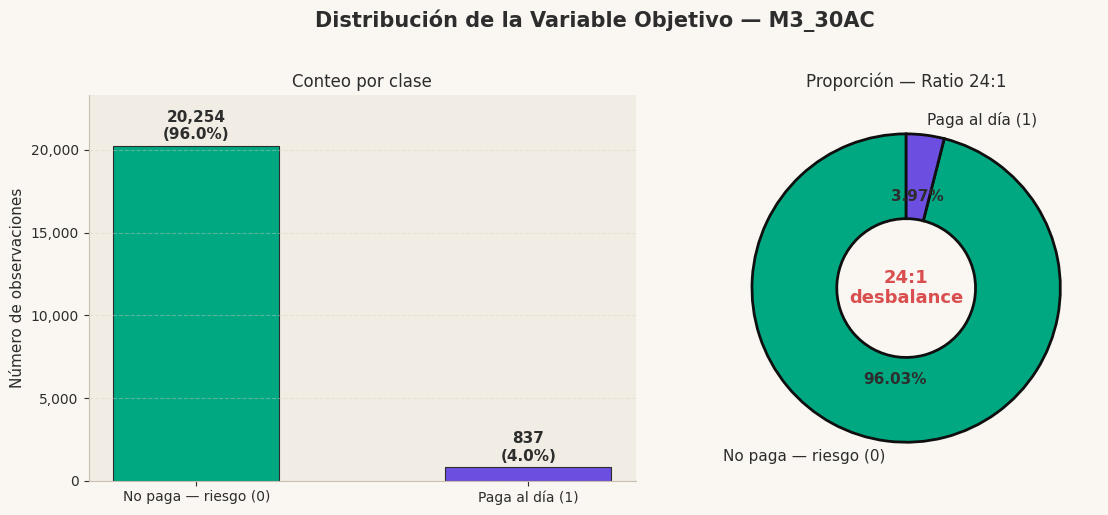

In [11]:
conteo = df['M3_30AC'].value_counts()
total  = len(df)
n_pos  = conteo[1]
n_neg  = conteo[0]
ratio  = n_neg / n_pos

print('=' * 55)
print('  DISTRIBUCIÓN DE LA VARIABLE OBJETIVO M3_30AC')
print('=' * 55)
print(f'  Clase 0 — No paga (riesgo)  : {n_neg:>6,}  ({n_neg/total*100:.2f}%)')
print(f'  Clase 1 — Paga al día  : {n_pos:>6,}  ({n_pos/total*100:.2f}%)')
print(f'  Total               : {total:>6,}')
print(f'  Ratio desbalance    : {ratio:.1f} : 1')
print('=' * 55)
print(f'\n  DESBALANCE SEVERO detectado ({ratio:.1f}:1). Se aplicará SMOTETomek.')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de la Variable Objetivo — M3_30AC',
             fontsize=15, fontweight='bold', color=COLOR_TEXT, y=1.02)

ax = axes[0]
bars = ax.bar(['No paga — riesgo (0)', 'Paga al día (1)'], [n_neg, n_pos],
              color=[COLOR_NEG, COLOR_POS], width=0.5, edgecolor=COLOR_TEXT, linewidth=0.8)
for bar, val in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({val/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, color=COLOR_TEXT, fontweight='bold')
ax.set_title('Conteo por clase', fontsize=12)
ax.set_ylabel('Número de observaciones')
ax.set_ylim(0, n_neg * 1.15)
ax.grid(axis='y', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    [n_neg, n_pos], labels=['No paga — riesgo (0)', 'Paga al día (1)'],
    autopct='%1.2f%%', colors=[COLOR_NEG, COLOR_POS], startangle=90,
    wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2, 'width': 0.55},
    textprops={'color': COLOR_TEXT, 'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title(f'Proporción — Ratio {ratio:.0f}:1', fontsize=12)
ax2.text(0, 0, f'{ratio:.0f}:1\ndesbalance', ha='center', va='center',
         fontsize=13, color=COLOR_WARN, fontweight='bold')

plt.tight_layout()
plt.savefig('00_distribucion_clases.png', dpi=150, bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación clases:** La distribución de la variable objetivo `M3_30AC` revela un desbalance de clases severo en el conjunto de datos. De los 21,091 clientes registrados, 20,254 (96.03%) corresponden a la clase 1 —clientes que pagaron en los primeros tres meses—, mientras que apenas 837 (3.97%) pertenecen a la clase 0, es decir, clientes que no cumplieron con su obligación de pago y representan el evento de interés para el modelo. Esta proporción genera un ratio de 24:1, lo que significa que por cada cliente en riesgo existe aproximadamente 24 que no lo están. En este contexto, entrenar un modelo directamente sobre los datos originales resultaría engañoso: un clasificador que predijera siempre la clase mayoritaria obtendría una exactitud global del 96%, pero fallaría completamente en identificar a los clientes en incumplimiento, que son precisamente los que se busca detectar. Por esta razón, se hace necesario aplicar técnicas de balanceo de clases antes del entrenamiento.

---
### 1.4 Tratamiento de valores nulos

Se identifican y cuantifican los valores faltantes por variable
y se define la estrategia de imputación más adecuada para cada caso.

 Variables con valores nulos:


,Nulos,% del total
IngresoEstimado,28,0.1328
CapacidadDePago,28,0.1328


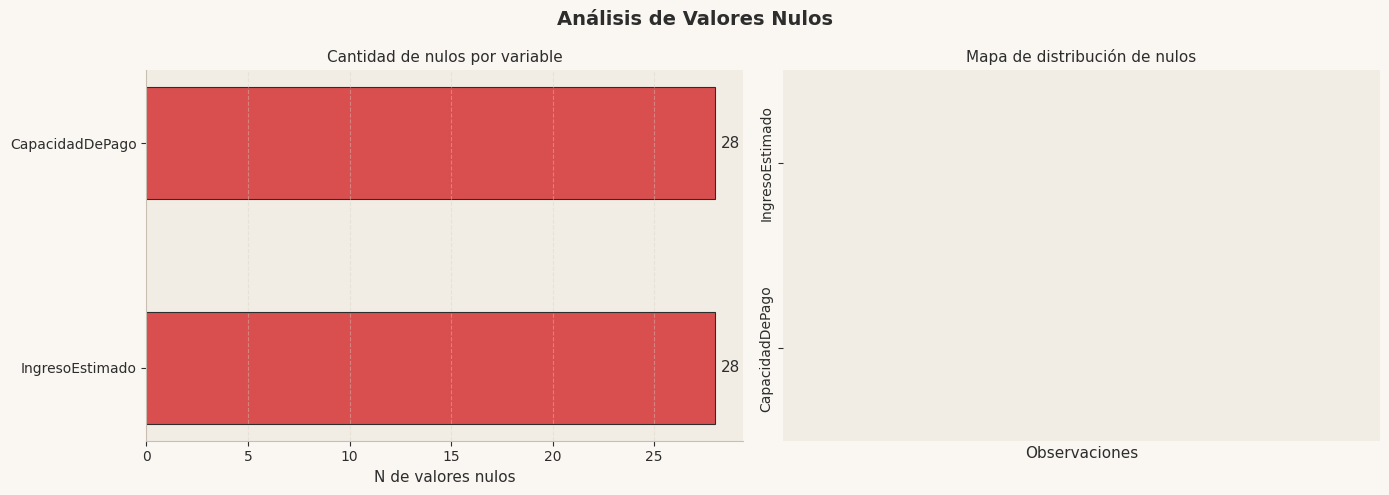

In [12]:
nulos = pd.DataFrame({
    'Nulos'      : df.isnull().sum(),
    '% del total': (df.isnull().sum() / len(df) * 100).round(4)
})
nulos = nulos[nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

if nulos.empty:
    print(' No se detectaron valores nulos en el dataset.')
else:
    print(' Variables con valores nulos:')
    display(nulos)

    vars_nulas = nulos.index.tolist()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Análisis de Valores Nulos', fontsize=14, fontweight='bold', color=COLOR_TEXT)

    ax = axes[0]
    vals = nulos['Nulos'].values
    bars = ax.barh(vars_nulas, vals, color=COLOR_WARN, edgecolor=COLOR_TEXT, linewidth=0.8, height=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=11, color=COLOR_TEXT)
    ax.set_title('Cantidad de nulos por variable', fontsize=11)
    ax.set_xlabel('N de valores nulos')
    ax.grid(axis='x', alpha=0.4)

    ax2 = axes[1]
    nulo_cols = df[vars_nulas].isnull().astype(int)
    sns.heatmap(nulo_cols.T, ax=ax2, cmap=['#F2EDE4', COLOR_WARN],
                cbar=False, yticklabels=vars_nulas, xticklabels=False, linewidths=0)
    ax2.set_title('Mapa de distribución de nulos', fontsize=11)
    ax2.set_xlabel('Observaciones')

    plt.tight_layout()
    plt.savefig('01_valores_nulos.png', dpi=150, bbox_inches='tight', facecolor=BG_SAVE)
    plt.show()

In [13]:
# Imputación con mediana por clase (robusta ante outliers)
for col in ['IngresoEstimado', 'CapacidadDePago']:
    if df[col].isnull().sum() > 0:
        mediana_por_clase = df.groupby('M3_30AC')[col].transform('median')
        antes = df[col].isnull().sum()
        df[col] = df[col].fillna(mediana_por_clase)
        df[col] = df[col].fillna(df[col].median())  # fallback global
        despues = df[col].isnull().sum()
        print(f' {col}: {antes} nulos imputados con mediana por clase → {despues} restantes')

print(f'\nNulos totales tras imputación: {df.isnull().sum().sum()}')

 IngresoEstimado: 28 nulos imputados con mediana por clase → 0 restantes
 CapacidadDePago: 28 nulos imputados con mediana por clase → 0 restantes

Nulos totales tras imputación: 0


**Decisión:** Las 28 observaciones con valores nulos (~0.13%) en `IngresoEstimado` y
`CapacidadDePago` se imputan con la **mediana por clase**. En este caso se usa esta estrategia debido a que no sabemos si uno de esos nulos pertecen a la clase ya escasa, en este caso son las personas que estan al dia, por lo que se decide conservar estos datos y evitar eliminar datos que pueden ser importantes

---
### 1.5 Tratamiento de duplicados

Se verifica la existencia de registros duplicados tanto en el dataset completo
como en la columna identificadora `Caso`.

In [14]:
dup_filas = df.duplicated().sum()
dup_caso  = df['Caso'].duplicated().sum()

print('=' * 45)
print('  VERIFICACIÓN DE DUPLICADOS')
print('=' * 45)
print(f'  Filas completamente duplicadas : {dup_filas}')
print(f'  IDs de Caso duplicados         : {dup_caso}')
print('=' * 45)

if dup_filas == 0 and dup_caso == 0:
    print('\n Nota: No se encontraron duplicados. El dataset es consistente.')
else:
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset='Caso', keep='first')
    print(f'Nota: Duplicados eliminados. Dataset: {df.shape[0]:,} filas')

  VERIFICACIÓN DE DUPLICADOS
  Filas completamente duplicadas : 0
  IDs de Caso duplicados         : 0

 Nota: No se encontraron duplicados. El dataset es consistente.


---
### 1.6 Análisis y tratamiento de outliers

Se aplica el **método IQR** para identificar valores extremos.
El tratamiento elegido es **winsorización al percentil 1–99**: conserva todas
las observaciones (crucial dado el desbalance) y reduce el impacto de extremos
sobre las redes neuronales, que son sensibles a la escala de los datos.

$$
\text{Límite inferior} = Q_1 - 1.5 \times IQR \qquad
\text{Límite superior} = Q_3 + 1.5 \times IQR
$$

In [15]:
vars_continuas = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion',
                  'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

resumen_outliers = []
for col in vars_continuas:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out   = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    resumen_outliers.append({
        'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'IQR': round(IQR, 2), 'Lím. inferior': round(lim_inf, 2),
        'Lím. superior': round(lim_sup, 2),
        'N outliers': n_out, '% outliers': round(n_out/len(df)*100, 2)
    })

df_out = pd.DataFrame(resumen_outliers).set_index('Variable')
print('Resumen de outliers (método IQR):')
display(df_out)

Resumen de outliers (método IQR):


,Q1,Q3,IQR,Lím. inferior,Lím. superior,N outliers,% outliers
Variable,,,,,,,
Edad,34.00,54.00,20.00,4.00,84.00,0,0.00
ScoreCrediticio,726.00,838.00,112.00,558.00,1006.00,11,0.05
PorcentajeFinanciacion,0.55,1.00,0.45,-0.12,1.67,0,0.00
IngresoEstimado,1597760.50,5791332.00,4193571.50,-4692596.75,12081689.25,1881,8.92
Gastos,1090507.16,2736073.24,1645566.08,-1377841.97,5204422.37,1555,7.37
CapacidadDePago,0.25,2.15,1.90,-2.60,5.00,2274,10.78
ValorCuotaMensual,1158444.00,2062300.00,903856.00,-197340.00,3418084.00,794,3.76


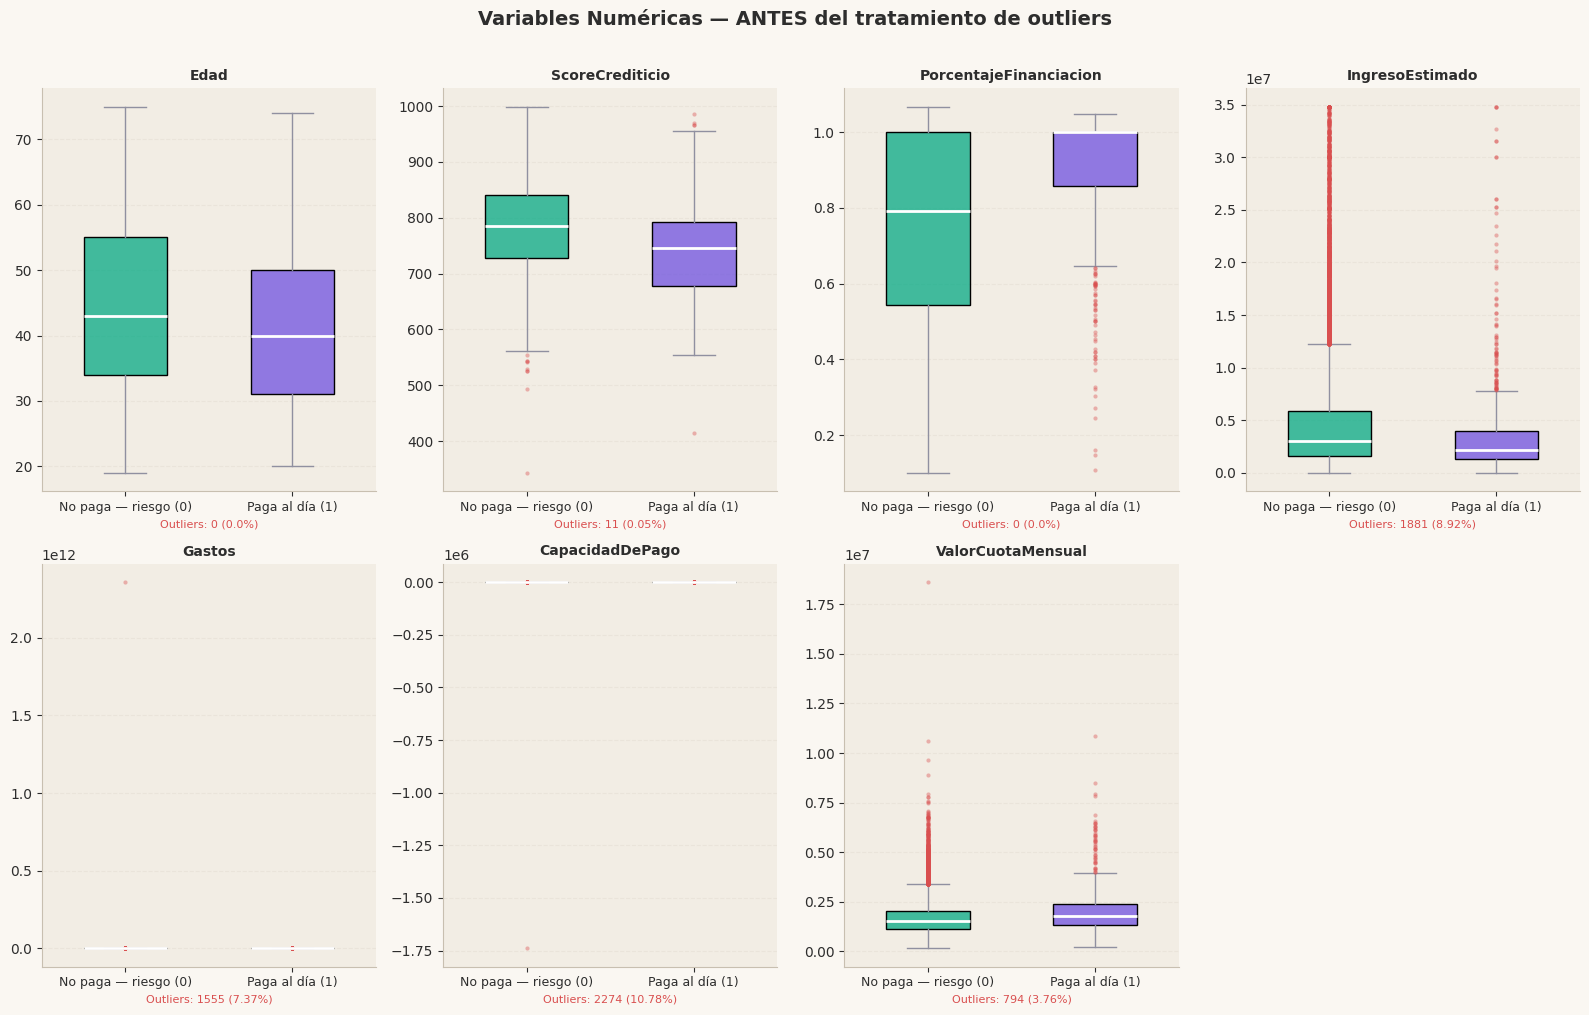

In [16]:
# Boxplots ANTES del tratamiento
n_cols = 4
n_rows = int(np.ceil(len(vars_continuas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()
fig.suptitle('Variables Numéricas — ANTES del tratamiento de outliers',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.01)

for i, col in enumerate(vars_continuas):
    ax = axes[i]
    data_0 = df[df['M3_30AC'] == 0][col].dropna()
    data_1 = df[df['M3_30AC'] == 1][col].dropna()
    bp = ax.boxplot([data_0, data_1], patch_artist=True, widths=0.5,
                    medianprops={'color': 'white', 'linewidth': 2},
                    whiskerprops={'color': '#9090A0'}, capprops={'color': '#9090A0'},
                    flierprops={'marker': 'o', 'markerfacecolor': COLOR_WARN,
                                'markersize': 3, 'alpha': 0.4, 'markeredgecolor': 'none'})
    bp['boxes'][0].set_facecolor(COLOR_NEG + 'BB')
    bp['boxes'][1].set_facecolor(COLOR_POS + 'BB')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xticklabels(['No paga — riesgo (0)', 'Paga al día (1)'], fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    n_out = df_out.loc[col, 'N outliers']
    pct   = df_out.loc[col, '% outliers']
    ax.set_xlabel(f'Outliers: {n_out} ({pct}%)', fontsize=8, color=COLOR_WARN)

for j in range(len(vars_continuas), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('02a_boxplots_antes.png', dpi=150, bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación de outliers:** Se identifica que hay dos variables criticas que contienen muchos outliers como lo son las variables `CapacidadDePago` e `IngresoEstimado`. La variable de ingresos puede ser normal debido a que si pueden haber clientes que ganen mucho más por lo que se hará una winsorizacion. Por otro lado, la variable de capacidad si tiene valores muy extraños que pueden deberse a un mal registro por lo que se decide reemplazar esos valores por la mediana de esta variable

In [17]:
# ─── Tratamiento diferenciado por variable ────────────────────────────────────
# · CapacidadDePago → imputación de outliers con mediana por clase
#   (valores extremos son errores de construcción, no comportamientos reales)
# · Resto de variables → winsorización P1–P99
#   (valores extremos son posibles pero influyentes)

df_clean = df.copy()

# ── Winsorización P1-P99 para variables numéricas (excepto CapacidadDePago) ──
vars_winsorizacion = ['ScoreCrediticio',
                      'IngresoEstimado', 'Gastos', 'ValorCuotaMensual']

print('Winsorización P1–P99:')
print(f'  {"Variable":<25} {"P1":>16} {"P99":>16}')
print('  ' + '-' * 58)
for col in vars_winsorizacion:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    print(f'  {col:<25} {p01:>16,.2f} {p99:>16,.2f}')

# ── Imputación por mediana por clase para CapacidadDePago ─────────────────────
print('\nImputación de outliers — CapacidadDePago:')
col = 'CapacidadDePago'
Q1  = df_clean[col].quantile(0.25)
Q3  = df_clean[col].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
mask_out = (df_clean[col] < lim_inf) | (df_clean[col] > lim_sup)
n_out = mask_out.sum()

# Mediana por clase excluyendo los propios outliers
mediana_por_clase = df_clean.groupby('M3_30AC')[col].transform(
    lambda x: x[~mask_out.loc[x.index]].median()
)
df_clean.loc[mask_out, col] = mediana_por_clase[mask_out]

print(f'  Outliers reemplazados : {n_out:,}')
print(f'  Criterio              : mediana por clase (sin outliers)')
print(f'  Límite inferior IQR   : {lim_inf:,.2f}')
print(f'  Límite superior IQR   : {lim_sup:,.2f}')

print(f'\nTratamiento completado. Dataset: {df_clean.shape}')

Winsorización P1–P99:
  Variable                                P1              P99
  ----------------------------------------------------------
  ScoreCrediticio                     605.00           986.00
  IngresoEstimado                       0.00    33,227,610.00
  Gastos                          497,918.58    11,496,338.81
  ValorCuotaMensual               383,472.50     4,799,430.40

Imputación de outliers — CapacidadDePago:
  Outliers reemplazados : 2,274
  Criterio              : mediana por clase (sin outliers)
  Límite inferior IQR   : -2.60
  Límite superior IQR   : 5.00

Tratamiento completado. Dataset: (21091, 13)


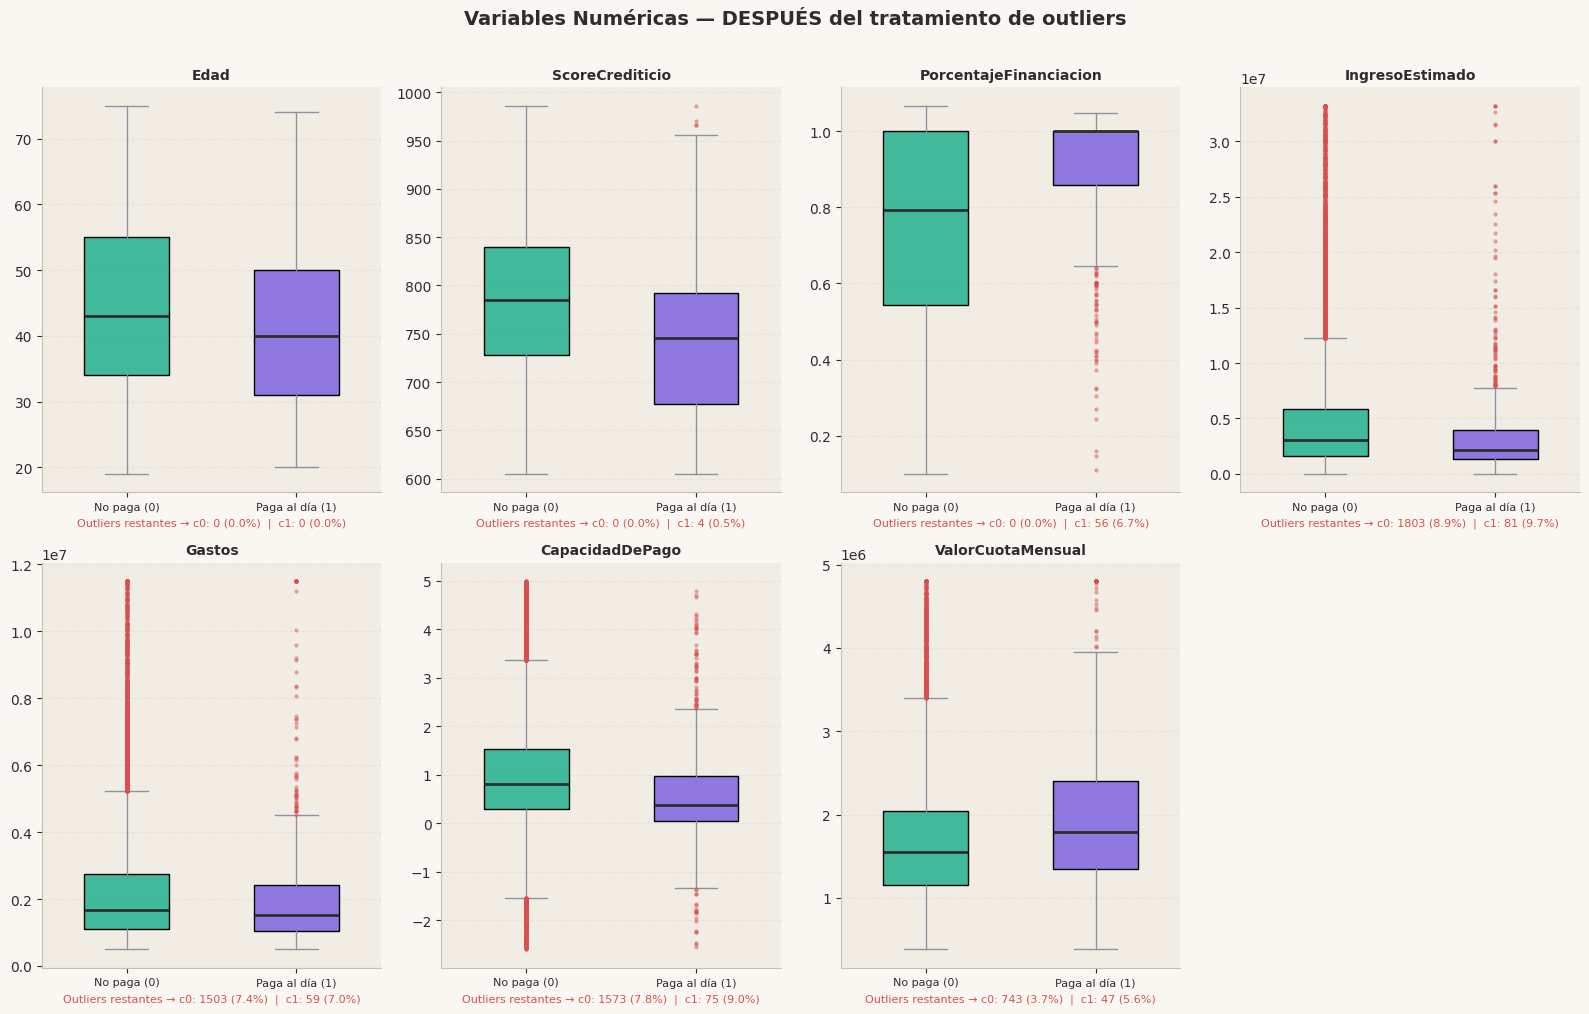

In [18]:
# ─── Boxplots DESPUÉS del tratamiento — con conteo y % de outliers restantes ──
vars_continuas = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion',
                  'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

n_cols = 4
n_rows = int(np.ceil(len(vars_continuas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()
fig.suptitle('Variables Numéricas — DESPUÉS del tratamiento de outliers',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.01)

for i, col in enumerate(vars_continuas):
    ax = axes[i]
    data_0 = df_clean[df_clean['M3_30AC'] == 0][col]
    data_1 = df_clean[df_clean['M3_30AC'] == 1][col]

    bp = ax.boxplot([data_0, data_1], patch_artist=True, widths=0.5,
                    medianprops={'color': COLOR_TEXT, 'linewidth': 2},
                    whiskerprops={'color': '#9090A0'},
                    capprops={'color': '#9090A0'},
                    flierprops={'marker': 'o', 'markerfacecolor': COLOR_WARN,
                                'markersize': 3, 'alpha': 0.5,
                                'markeredgecolor': 'none'})
    bp['boxes'][0].set_facecolor(COLOR_NEG + 'BB')
    bp['boxes'][1].set_facecolor(COLOR_POS + 'BB')

    # ── Conteo y % de outliers restantes por clase ────────────────────────────
    partes = []
    for datos, clase in [(data_0, '0'), (data_1, '1')]:
        q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
        iqr    = q3 - q1
        n_out  = ((datos < q1 - 1.5*iqr) | (datos > q3 + 1.5*iqr)).sum()
        pct    = n_out / len(datos) * 100
        partes.append(f'c{clase}: {n_out} ({pct:.1f}%)')

    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xticklabels(['No paga (0)', 'Paga al día (1)'], fontsize=8)
    ax.grid(axis='y', alpha=0.4)
    ax.set_xlabel(
        f'Outliers restantes → {partes[0]}  |  {partes[1]}',
        fontsize=8, color=COLOR_WARN
    )

for j in range(len(vars_continuas), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('02b_boxplots_despues.png', dpi=150, bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación final outliers:** El tratamiento de outliers ayudó un poco en el manejo de outliers principalmente a la variable de capacidad que era la más afectada por inconsistencias. Aunque la winsorizacion no bajo en gran magnitud los outliers de las otras variables, logra bajar un poco la cantidad de outliers presentes.

---
### 1.7 Codificación de variables categóricas

Las variables `Perfil`, `Estado` y `Genero` son binarias (2 categorías cada una),
por lo que se aplica **Label Encoding**. La columna `Caso` se elimina por ser
un identificador único sin valor predictivo.

In [19]:
vars_cat = df_clean.select_dtypes(include='object').columns.tolist()
print('Variables categóricas encontradas:')
for col in vars_cat:
    print(f'  {col:<10}: {df_clean[col].unique().tolist()}')

Variables categóricas encontradas:
  Perfil    : ['ASALARIADO', 'INDEPENDIENTE']
  Estado    : ['NUEVO', 'USADO']
  Genero    : ['FEMENINO', 'MASCULINO']


In [20]:
le = LabelEncoder()
mapeos = {}

for col in vars_cat:
    df_clean[col] = le.fit_transform(df_clean[col])
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f' {col}: {mapeos[col]}')

df_clean = df_clean.drop(columns=['Caso'])
print(f'\n Columna Caso eliminada (identificador sin valor predictivo).')
print(f'Dataset: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas')
display(df_clean.head())

 Perfil: {'ASALARIADO': np.int64(0), 'INDEPENDIENTE': np.int64(1)}
 Estado: {'NUEVO': np.int64(0), 'USADO': np.int64(1)}
 Genero: {'FEMENINO': np.int64(0), 'MASCULINO': np.int64(1)}

 Columna Caso eliminada (identificador sin valor predictivo).
Dataset: 21,091 filas x 12 columnas


,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,0,0,30,0,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693.0,0
1,1,0,46,1,670,0.2783,60,2425440.0,1621788.08,0.948770,847046.0,0
2,1,1,39,1,752,1.0000,60,30000000.0,3614018.63,0.813251,2197145.0,0
3,0,1,38,0,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896.0,0
4,1,0,60,0,846,0.6596,72,20907400.0,3439341.88,0.813251,1343222.0,0


### 1.8 Tratamiento del desbalance de clases (undersampling)

In [21]:
# ── Undersampling sobre df_clean completo ─────────────────────────────────────
from imblearn.under_sampling import RandomUnderSampler

X_full = df_clean.drop(columns=['M3_30AC'])
y_full = df_clean['M3_30AC']

print('Distribución original:')
print(f'  Clase 0 (no paga) : {(y_full==0).sum():,}')
print(f'  Clase 1 (paga)    : {(y_full==1).sum():,}')

# Clase 0: ~1,200 | Clase 1: ~700
# sampling_strategy = clase_minoritaria / clase_mayoritaria
# clase minoritaria es clase 1 con 837
# queremos clase 0 = 1200 → strategy = 837/1200 ≈ 0.6975
# para bajar clase 1 a ~700 usamos sampling_strategy sobre clase 1

rus_cnuevo = RandomUnderSampler(
    sampling_strategy={0: 1200, 1: 700},
    random_state=42
)

X_under_arr, y_under_arr = rus_cnuevo.fit_resample(X_full, y_full)

X_under = pd.DataFrame(X_under_arr, columns=X_full.columns)
y_under = pd.Series(y_under_arr, name='M3_30AC')

conteo = y_under.value_counts()
print('\nDespués del undersampling:')
print(f'  Clase 0 (no paga) : {conteo[0]:,}')
print(f'  Clase 1 (paga)    : {conteo[1]:,}')
print(f'  Total             : {len(X_under):,}')
print(f'  Ratio             : {conteo[0]/conteo[1]:.2f}:1')

Distribución original:
  Clase 0 (no paga) : 20,254
  Clase 1 (paga)    : 837

Después del undersampling:
  Clase 0 (no paga) : 1,200
  Clase 1 (paga)    : 700
  Total             : 1,900
  Ratio             : 1.71:1


---
### 1.9 Escalado de variables numéricas

Las redes neuronales son sensibles a la escala. Con variables en rangos tan
distintos (`ScoreCrediticio` en cientos vs `IngresoEstimado` en millones), el
gradiente puede ser dominado por las variables de mayor magnitud.

Se aplica **StandardScaler** que transforma cada variable a media 0 y desviación 1:

$$z = \frac{x - \mu}{\sigma}$$

El scaler se **ajusta solo sobre el train** y se aplica a ambas particiones.

In [22]:
# ── Split estratificado 80/20 sobre los datos balanceados ─────────────────────
X_train_cn, X_test_cn, y_train_cn, y_test_cn = train_test_split(
    X_under, y_under,
    test_size=0.20,
    random_state=42,
    stratify=y_under
)

print('Split completado:')
print(f'\nTrain:')
print(f'  Clase 0 : {(y_train_cn==0).sum():,}')
print(f'  Clase 1 : {(y_train_cn==1).sum():,}')
print(f'  Total   : {len(X_train_cn):,}')
print(f'\nTest:')
print(f'  Clase 0 : {(y_test_cn==0).sum():,}')
print(f'  Clase 1 : {(y_test_cn==1).sum():,}')
print(f'  Total   : {len(X_test_cn):,}')

# ── Escalado variables numéricas — StandardScaler ─────────────────────────────
# Fit solo en train, transform en ambos
scaler_cn = StandardScaler()

vars_escalar_cn = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
                   'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

X_train_cn_scaled = X_train_cn.copy()
X_test_cn_scaled  = X_test_cn.copy()

X_train_cn_scaled[vars_escalar_cn] = scaler_cn.fit_transform(
    X_train_cn[vars_escalar_cn])
X_test_cn_scaled[vars_escalar_cn]  = scaler_cn.transform(
    X_test_cn[vars_escalar_cn])

print('\n Escalado completado.')
print(f'   Scaler ajustado solo en train — sin data leakage')

# ── Convertir a numpy para el modelo ─────────────────────────────────────────
X_tr_cn = X_train_cn_scaled.values
y_tr_cn = y_train_cn.values
X_te_cn = X_test_cn_scaled.values
y_te_cn = y_test_cn.values

print(f'\nX_tr_cn : {X_tr_cn.shape}')
print(f'X_te_cn : {X_te_cn.shape}')

Split completado:

Train:
  Clase 0 : 960
  Clase 1 : 560
  Total   : 1,520

Test:
  Clase 0 : 240
  Clase 1 : 140
  Total   : 380

 Escalado completado.
   Scaler ajustado solo en train — sin data leakage

X_tr_cn : (1520, 11)
X_te_cn : (380, 11)


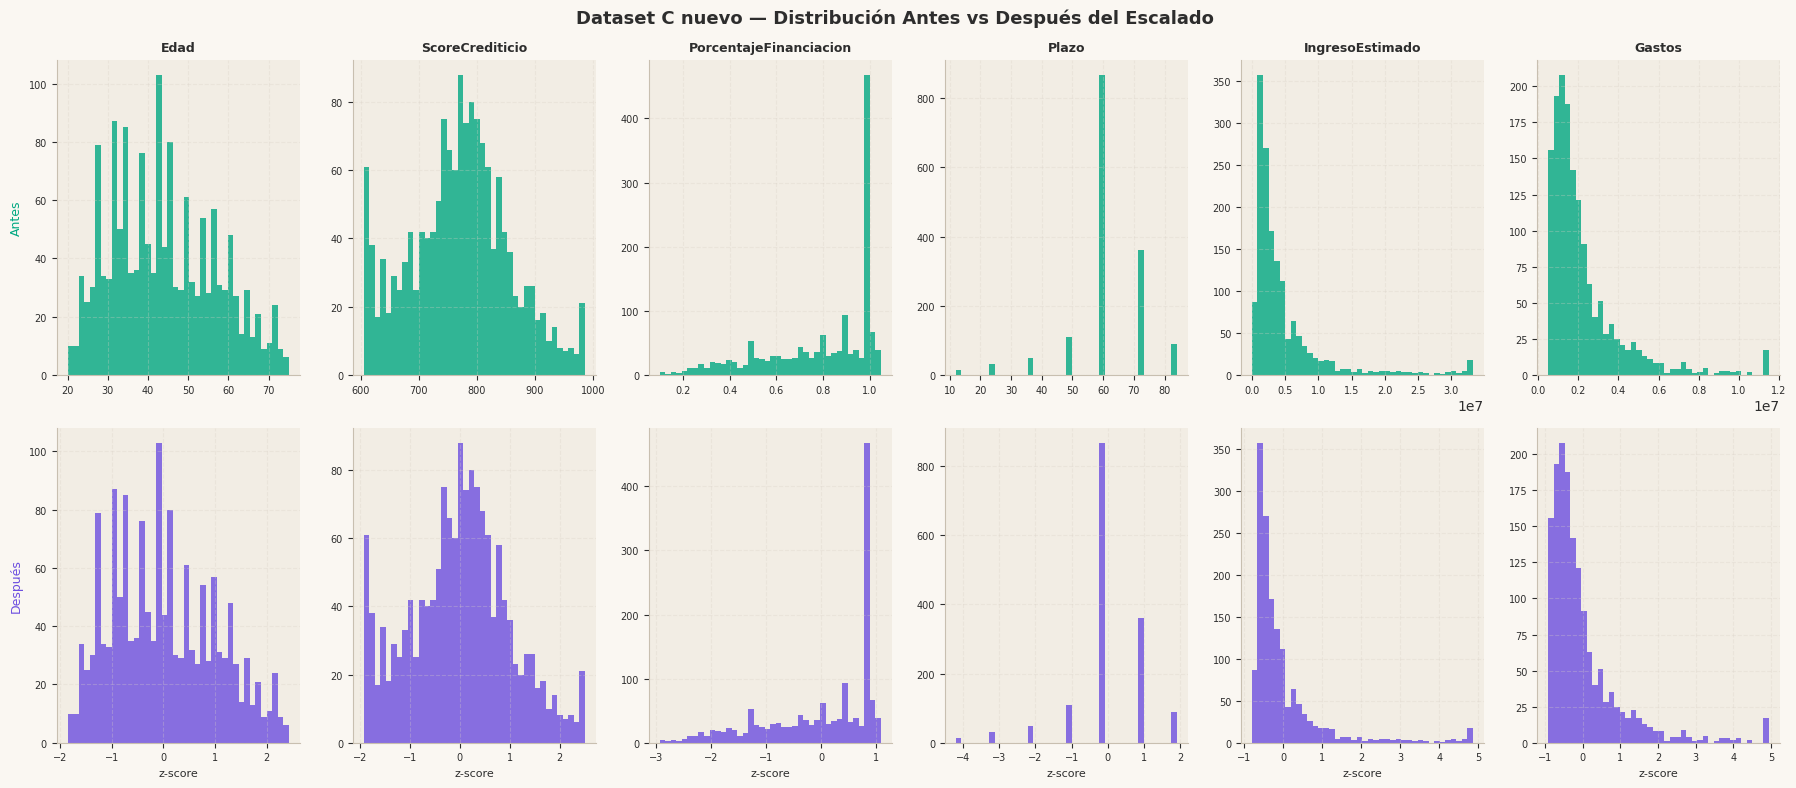

In [23]:
# ── Distribución antes vs después del escalado — Dataset C nuevo ──────────────
vars_vis_cn = vars_escalar_cn[:6]

fig, axes = plt.subplots(2, len(vars_vis_cn), figsize=(18, 8))
fig.suptitle('Dataset C nuevo — Distribución Antes vs Después del Escalado',
             fontsize=13, fontweight='bold', color=COLOR_TEXT)

for i, col in enumerate(vars_vis_cn):
    # Fila 0: antes del escalado
    ax0 = axes[0][i]
    ax0.set_facecolor(BG_AXES)
    ax0.hist(X_train_cn[col], bins=40, color=COLOR_NEG,
             alpha=0.8, edgecolor='none')
    ax0.set_title(col, fontsize=9, fontweight='bold')
    if i == 0: ax0.set_ylabel('Antes', fontsize=9, color=COLOR_NEG)
    ax0.grid(alpha=0.3)
    ax0.tick_params(labelsize=7)

    # Fila 1: después del escalado
    ax1 = axes[1][i]
    ax1.set_facecolor(BG_AXES)
    ax1.hist(X_train_cn_scaled[col], bins=40, color=COLOR_POS,
             alpha=0.8, edgecolor='none')
    if i == 0: ax1.set_ylabel('Después', fontsize=9, color=COLOR_POS)
    ax1.grid(alpha=0.3)
    ax1.tick_params(labelsize=7)
    ax1.set_xlabel('z-score', fontsize=8)

plt.tight_layout()
plt.savefig('escalado_C_nuevo.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

---
### 1.10 Exportación del dataset limpio

Se guardan los conjuntos de entrenamiento y prueba procesados en formato `.csv`
para uso en las siguientes fases del proyecto.

In [24]:
# ── Exportación Dataset C nuevo ───────────────────────────────────────────────
train_cn_final = pd.concat([
    X_train_cn_scaled.reset_index(drop=True),
    y_train_cn.reset_index(drop=True)
], axis=1)

test_cn_final = pd.concat([
    X_test_cn_scaled.reset_index(drop=True),
    y_test_cn.reset_index(drop=True)
], axis=1)

train_cn_final.to_csv('train_C_nuevo.csv', index=False)
test_cn_final.to_csv('test_C_nuevo.csv',   index=False)

print('=' * 55)
print('  RESUMEN FINAL — DATASET C NUEVO EXPORTADO')
print('=' * 55)
print(f'  train_C_nuevo.csv : {train_cn_final.shape[0]:,} x {train_cn_final.shape[1]}')
print(f'    Clase 0 (paga)        : {(train_cn_final["M3_30AC"]==0).sum():,}')
print(f'    Clase 1 (no paga)     : {(train_cn_final["M3_30AC"]==1).sum():,}')
print(f'  test_C_nuevo.csv  : {test_cn_final.shape[0]:,} x {test_cn_final.shape[1]}')
print(f'    Clase 0 (paga)        : {(test_cn_final["M3_30AC"]==0).sum():,}')
print(f'    Clase 1 (no paga)     : {(test_cn_final["M3_30AC"]==1).sum():,}')
print('=' * 55)
print('\n Exportación completada.')

  RESUMEN FINAL — DATASET C NUEVO EXPORTADO
  train_C_nuevo.csv : 1,520 x 12
    Clase 0 (paga)        : 960
    Clase 1 (no paga)     : 560
  test_C_nuevo.csv  : 380 x 12
    Clase 0 (paga)        : 240
    Clase 1 (no paga)     : 140

 Exportación completada.


### Analisis EDA - dataset original

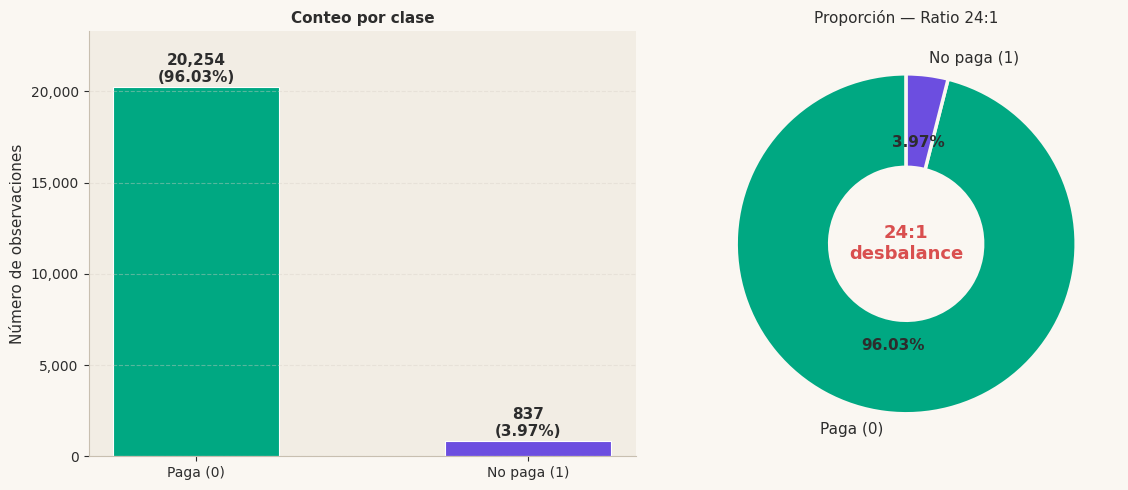

Clase 0 (paga)    : 20,254 (96.03%)
Clase 1 (no paga) : 837 (3.97%)
Ratio             : 24.2:1


In [25]:
# ── Figura 0: Distribución de clases — dataset original ──────────────────────
conteo_orig = df_clean['M3_30AC'].value_counts()
total_orig  = len(df_clean)
ratio_orig  = conteo_orig[0] / conteo_orig[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#fig.suptitle('Figura 1. Distribución de la variable objetivo — M3_30AC',
             #fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.02)

# Barplot
ax = axes[0]
ax.set_facecolor(BG_AXES)
bars = ax.bar(['Paga (0)', 'No paga (1)'],
              [conteo_orig[0], conteo_orig[1]],
              color=[COLOR_NEG, COLOR_POS],
              width=0.5, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, [conteo_orig[0], conteo_orig[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}\n({val/total_orig*100:.2f}%)',
            ha='center', va='bottom', fontsize=11,
            color=COLOR_TEXT, fontweight='bold')
ax.set_title('Conteo por clase', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de observaciones')
ax.set_ylim(0, conteo_orig[0] * 1.15)
ax.grid(axis='y', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Donut
ax2 = axes[1]
ax2.set_facecolor(BG_AXES)
wedges, texts, autotexts = ax2.pie(
    [conteo_orig[0], conteo_orig[1]],
    labels=['Paga (0)', 'No paga (1)'],
    autopct='%1.2f%%',
    colors=[COLOR_NEG, COLOR_POS],
    startangle=90,
    wedgeprops={'edgecolor': BG_MAIN, 'linewidth': 2.5, 'width': 0.55},
    textprops={'color': COLOR_TEXT, 'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_facecolor(BG_AXES)
ax2.set_title(f'Proporción — Ratio {ratio_orig:.0f}:1', fontsize=11)
ax2.text(0, 0, f'{ratio_orig:.0f}:1\ndesbalance', ha='center', va='center',
         fontsize=13, color=COLOR_WARN, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_00_clases.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

print(f'Clase 0 (paga)    : {conteo_orig[0]:,} ({conteo_orig[0]/total_orig*100:.2f}%)')
print(f'Clase 1 (no paga) : {conteo_orig[1]:,} ({conteo_orig[1]/total_orig*100:.2f}%)')
print(f'Ratio             : {ratio_orig:.1f}:1')

**Interpretación — Figura 0.** La distribución de la variable objetivo `M3_30AC`
revela un desbalance de clases severo en el dataset original. De los 21,091
clientes registrados, 20,254 (96.03%) corresponden a la clase 0 — clientes que
pagaron en los primeros tres meses — mientras que apenas 837 (3.97%) pertenecen
a la clase 1, es decir, clientes que no cumplieron con su obligación de pago y
representan el evento de interés para el modelo.

Esta proporción genera un ratio de 24:1, lo que significa que por cada cliente
en riesgo existen aproximadamente 24 que pagan sin problema. En este contexto,
entrenar un modelo directamente sobre los datos originales resultaría engañoso:
un clasificador que predijera siempre la clase mayoritaria obtendría una
exactitud global del 96%, pero fallaría completamente en identificar a los
clientes en incumplimiento, que son precisamente los que se busca detectar.

Por esta razón, se hace necesario aplicar técnicas de balanceo de clases antes
del entrenamiento. En este trabajo se optó por una estrategia de undersampling
controlado que reduce la clase mayoritaria a aproximadamente 1,200 observaciones
conservando todos los 837 clientes de la clase minoritaria, logrando un dataset
de entrenamiento más equilibrado que permite al modelo aprender los patrones
de ambas clases sin sesgarse hacia la mayoritaria.

Dataset original:
  Clase 0 (paga)    : 20,254
  Clase 1 (no paga) : 837
  Tasa global no pago: 3.97%


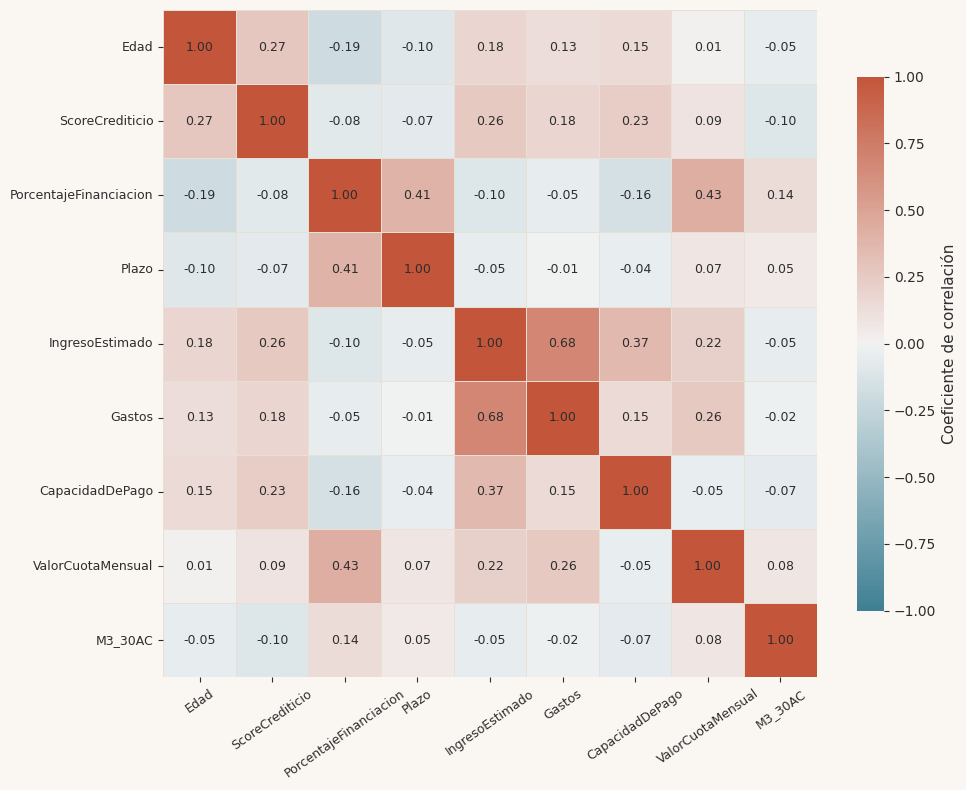

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# FASE 2 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# Sobre df_clean — datos originales sin balanceo
# ═══════════════════════════════════════════════════════════════════════════════

d0 = df_clean[df_clean['M3_30AC'] == 0]
d1 = df_clean[df_clean['M3_30AC'] == 1]

tasa_global = (df_clean['M3_30AC'] == 1).mean() * 100

print(f'Dataset original:')
print(f'  Clase 0 (paga)    : {(df_clean["M3_30AC"]==0).sum():,}')
print(f'  Clase 1 (no paga) : {(df_clean["M3_30AC"]==1).sum():,}')
print(f'  Tasa global no pago: {tasa_global:.2f}%')

# ── Figura 1: Matriz de correlaciones ─────────────────────────────────────────
vars_num = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
            'IngresoEstimado', 'Gastos', 'CapacidadDePago',
            'ValorCuotaMensual', 'M3_30AC']

corr = df_clean[vars_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG_MAIN)
ax.set_facecolor(BG_AXES)

cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr, ax=ax, cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9, 'color': COLOR_TEXT},
    linewidths=0.5, linecolor='#E8E0D5',
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'}
)

ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('eda_01_correlaciones.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 1.** La matriz de correlaciones revela que ninguna
variable presenta una correlación fuerte con la variable objetivo `M3_30AC`.
La relación más destacada es la de `PorcentajeFinanciacion` (0.14) y
`ValorCuotaMensual` (0.08), que sugieren una asociación positiva con el riesgo
de no pago — a mayor porcentaje financiado y mayor cuota, mayor probabilidad
de incumplimiento. En contraste, `ScoreCrediticio` (-0.10) muestra la relación
inversa esperada: mejores puntajes crediticios están asociados con menor
probabilidad de no pago.

Entre las variables predictoras se identifican correlaciones relevantes que
anticipan posible multicolinealidad. `IngresoEstimado` y `Gastos` presentan
una correlación alta (0.68), lo que es coherente dado que clientes con mayores
ingresos tienden a tener mayores gastos. `PorcentajeFinanciacion` y `Plazo`
también muestran una correlación moderada (0.41), sugiriendo que créditos a
mayor plazo tienden a financiar una proporción más alta del bien. Finalmente,
`PorcentajeFinanciacion` y `ValorCuotaMensual` presentan correlación de 0.43,
lo que indica que financiar más del bien implica cuotas más altas.

En conjunto, las correlaciones bajas con `M3_30AC` indican que ninguna variable
por sí sola es suficiente para predecir el incumplimiento, lo que justifica el
uso de un modelo no lineal como la red neuronal, capaz de capturar relaciones
complejas entre variables.

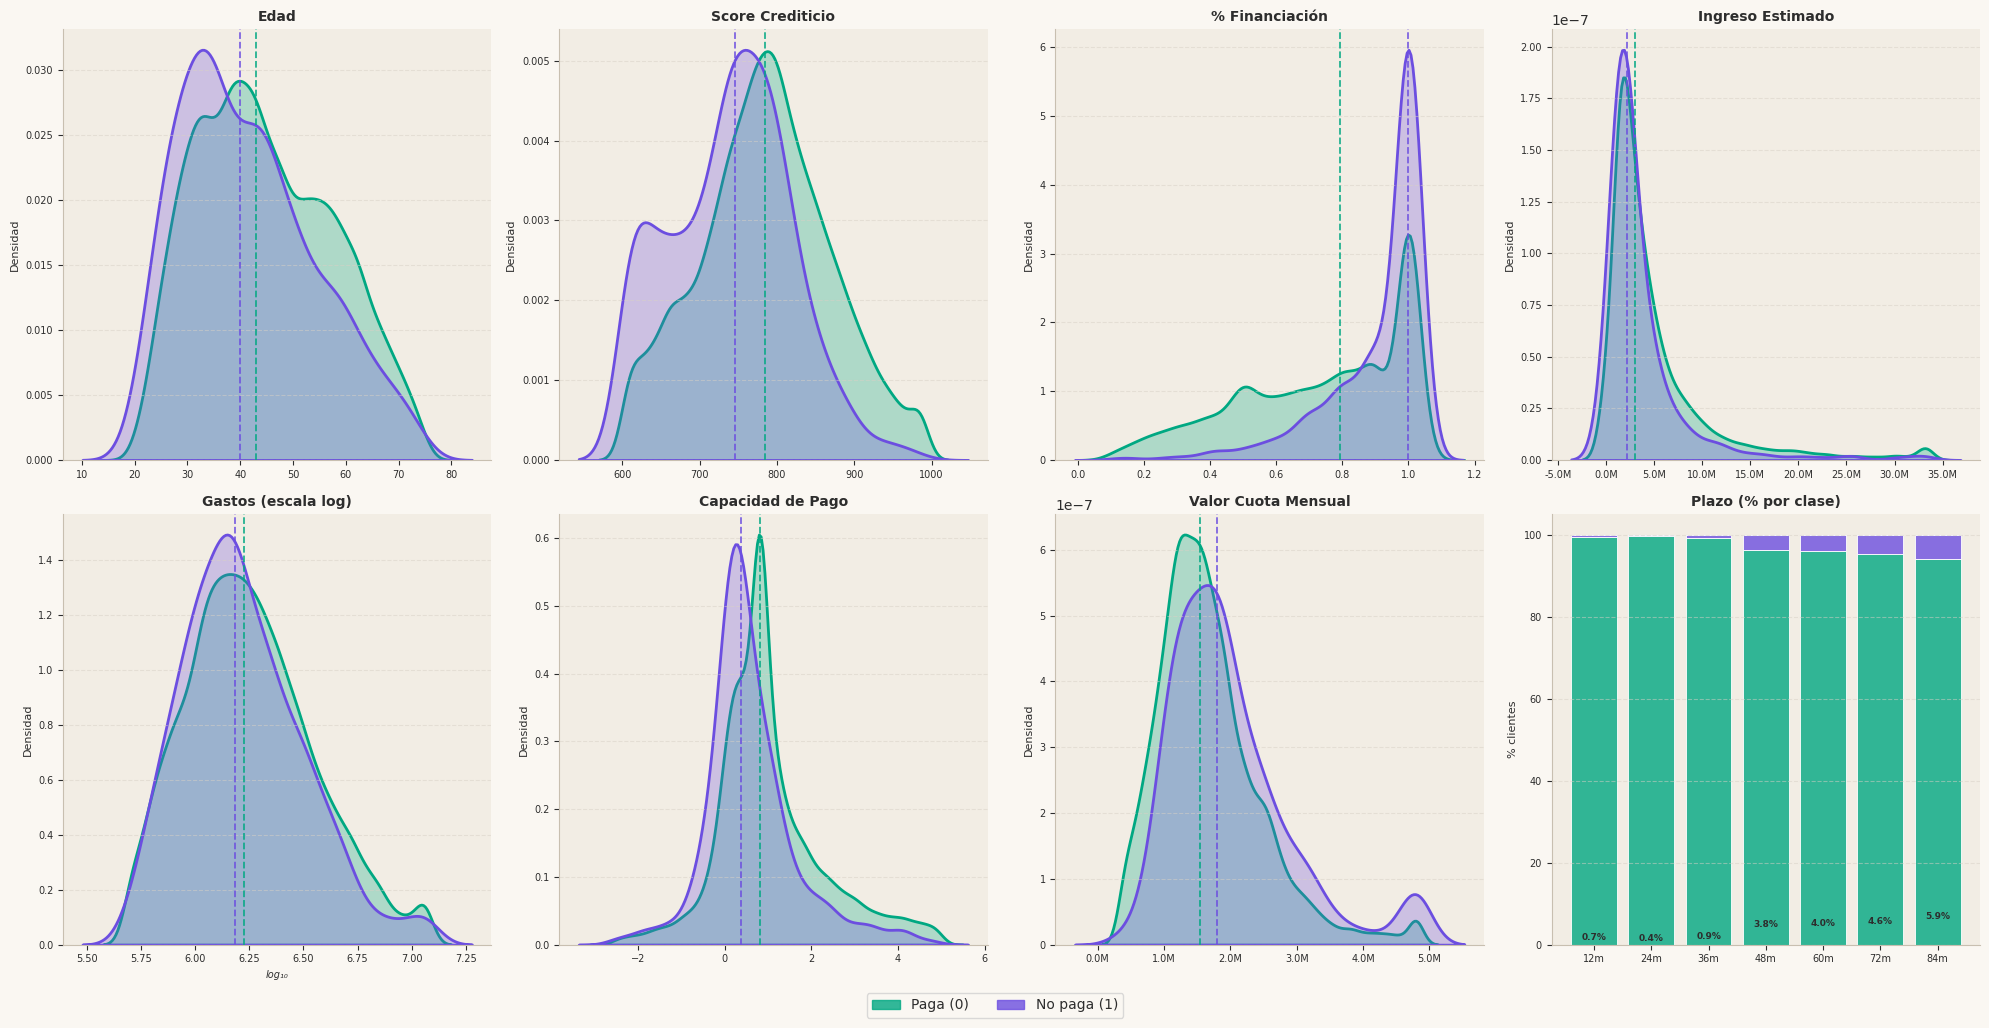

In [27]:
# ── Figura 2: Distribución de densidad por variable y clase ───────────────────
vars_config = [
    ('Edad',                  'Edad',                False),
    ('ScoreCrediticio',       'Score Crediticio',     False),
    ('PorcentajeFinanciacion','% Financiación',       False),
    ('IngresoEstimado',       'Ingreso Estimado',     False),
    ('Gastos',                'Gastos (escala log)',  True),
    ('CapacidadDePago',       'Capacidad de Pago',    False),
    ('ValorCuotaMensual',     'Valor Cuota Mensual',  False),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (col, label, usar_log) in enumerate(vars_config):
    ax = axes[i]
    ax.set_facecolor(BG_AXES)

    data0 = np.log10(d0[col].dropna()) if usar_log else d0[col].dropna()
    data1 = np.log10(d1[col].dropna()) if usar_log else d1[col].dropna()

    sns.kdeplot(data0, ax=ax, color=COLOR_NEG, linewidth=2,
                fill=True, alpha=0.28, label='Paga (0)')
    sns.kdeplot(data1, ax=ax, color=COLOR_POS, linewidth=2,
                fill=True, alpha=0.28, label='No paga (1)')

    for datos, color in [(data0, COLOR_NEG), (data1, COLOR_POS)]:
        ax.axvline(datos.median(), color=color, linestyle='--',
                   linewidth=1.3, alpha=0.85)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Densidad', fontsize=8)
    ax.set_xlabel('log₁₀' if usar_log else '', fontsize=7, style='italic')
    ax.grid(axis='y', alpha=0.5)
    ax.tick_params(labelsize=7)

    vars_millones = ['IngresoEstimado', 'ValorCuotaMensual']
    if not usar_log and col in vars_millones:
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Panel 8: Plazo como barras apiladas
ax8 = axes[7]
ax8.set_facecolor(BG_AXES)
plazos_rep = sorted(df_clean['Plazo'].value_counts()[
    df_clean['Plazo'].value_counts() >= 100].index)
df_p = df_clean[df_clean['Plazo'].isin(plazos_rep)]
tasa_p = df_p.groupby('Plazo').apply(
    lambda x: pd.Series({
        'pct_0': (x['M3_30AC']==0).sum()/len(x)*100,
        'pct_1': (x['M3_30AC']==1).sum()/len(x)*100,
    })
).reset_index()
x_pos = np.arange(len(tasa_p))
ax8.bar(x_pos, tasa_p['pct_0'], color=COLOR_NEG+'CC',
        edgecolor='white', linewidth=0.6, label='Paga (0)')
ax8.bar(x_pos, tasa_p['pct_1'], bottom=tasa_p['pct_0'],
        color=COLOR_POS+'CC', edgecolor='white', linewidth=0.6,
        label='No paga (1)')
ax8.set_xticks(x_pos)
ax8.set_xticklabels([f'{p}m' for p in tasa_p['Plazo']], fontsize=7.5)
for idx_b, row in tasa_p.iterrows():
    ax8.text(idx_b, row['pct_1'] + 0.5, f"{row['pct_1']:.1f}%",
             ha='center', fontsize=6.5, color=COLOR_TEXT, fontweight='bold')
ax8.set_title('Plazo (% por clase)', fontsize=10, fontweight='bold')
ax8.set_ylabel('% clientes', fontsize=8)
ax8.set_ylim(0, 105)
ax8.grid(axis='y', alpha=0.5)
ax8.tick_params(labelsize=7)

patch0 = mpatches.Patch(color=COLOR_NEG+'CC', label='Paga (0)')
patch1 = mpatches.Patch(color=COLOR_POS+'CC', label='No paga (1)')
fig.legend(handles=[patch0, patch1], loc='lower center', ncol=2,
           fontsize=10, framealpha=0.7, facecolor=BG_MAIN,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('eda_02_densidad.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 2.** La distribución de densidad por variable y clase
revela que ambas clases comparten formas similares en la mayoría de variables,
lo que refleja el severo desbalance del dataset original donde la clase que paga
domina ampliamente. Sin embargo, se identifican diferencias relevantes en
algunas variables.

`ScoreCrediticio` muestra el desplazamiento más notable entre clases — los
clientes que no pagan presentan una distribución concentrada en scores más bajos,
mientras que los que pagan se desplazan hacia scores más altos, confirmando su
capacidad discriminante. `PorcentajeFinanciacion` exhibe un comportamiento
bimodal en ambas clases, con un pico pronunciado cerca del 100% de financiación,
siendo más marcado en la clase de riesgo — indicando que financiar la totalidad
del bien está fuertemente asociado con incumplimiento.

`Edad` muestra que los clientes que no pagan tienden a ser más jóvenes, con
una distribución ligeramente desplazada hacia la izquierda respecto a los que
sí pagan. `CapacidadDePago` presenta distribuciones muy similares entre clases
con medianas prácticamente iguales, lo que limita su aporte discriminante
individual. `Gastos` en escala logarítmica y `ValorCuotaMensual` muestran
distribuciones casi idénticas entre clases, sugiriendo bajo poder predictivo
de forma aislada. `IngresoEstimado` presenta una distribución muy concentrada
cerca de cero con colas largas hacia la derecha en ambas clases, sin diferencias
apreciables entre ellas, lo que indica que el nivel de ingreso por sí solo no
determina el comportamiento de pago.

En el panel de `Plazo`, se evidencia que la proporción de clientes que no pagan
aumenta con la duración del crédito — los plazos de 72 y 84 meses concentran
las tasas más altas de incumplimiento. En conjunto, `ScoreCrediticio`,
`PorcentajeFinanciacion` y `Edad` emergen como las variables con mayor
capacidad para separar las clases.

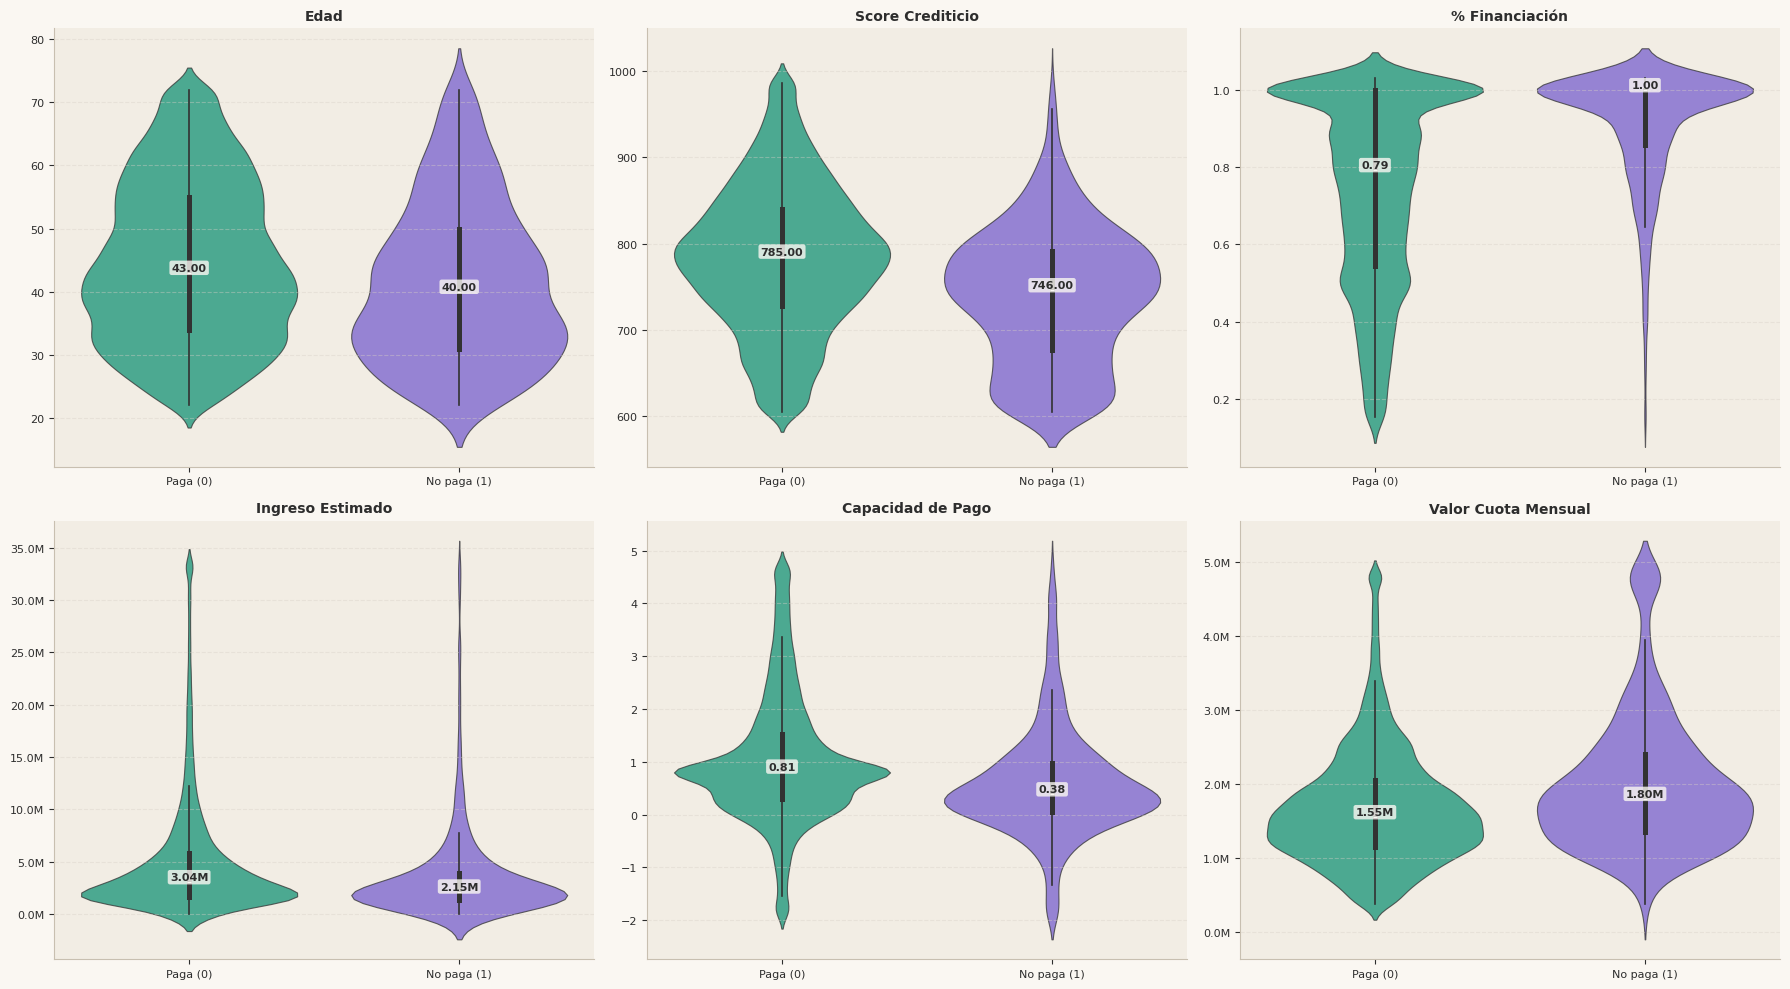

In [29]:
# ── Figura 3: Violin plot por variable y clase ────────────────────────────────
vars_violin = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion',
               'IngresoEstimado', 'CapacidadDePago', 'ValorCuotaMensual']
labels_v    = ['Edad', 'Score Crediticio', '% Financiación',
               'Ingreso Estimado', 'Capacidad de Pago', 'Valor Cuota Mensual']

df_clean['Clase'] = df_clean['M3_30AC'].map({0: 'Paga (0)', 1: 'No paga (1)'})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


for i, (col, label) in enumerate(zip(vars_violin, labels_v)):
    ax = axes[i]
    ax.set_facecolor(BG_AXES)

    # Winsorizar para visualización limpia
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    df_plot = df_clean.copy()
    df_plot[col] = df_plot[col].clip(p01, p99)

    sns.violinplot(
        data=df_plot, x='Clase', y=col, ax=ax,
        palette={'Paga (0)': COLOR_NEG, 'No paga (1)': COLOR_POS},
        inner='box',
        linewidth=0.8,
        alpha=0.75,
        order=['Paga (0)', 'No paga (1)']
    )

    # Medianas anotadas
    for j, clase in enumerate([0, 1]):
        med = df_clean[df_clean['M3_30AC'] == clase][col].median()
        fmt = f'{med/1e6:.2f}M' if df_clean[col].max() > 100000 else f'{med:.2f}'
        ax.text(j, med, fmt, ha='center', va='bottom',
                fontsize=8, color=COLOR_TEXT, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=BG_MAIN,
                          edgecolor='none', alpha=0.8))

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.4)
    ax.tick_params(labelsize=8)

    if df_clean[col].max() > 100000:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('eda_03_violin.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 3.** El violin plot permite observar simultáneamente
la forma completa de la distribución, la mediana y la dispersión de cada
variable por clase, ofreciendo una visión más rica que el boxplot tradicional.

`ScoreCrediticio` muestra la diferencia más clara entre clases — los clientes
que pagan presentan una distribución más concentrada en scores altos (mediana
785), mientras que los que no pagan tienen una distribución más dispersa
desplazada hacia scores más bajos (mediana 746), confirmando su capacidad
discriminante. `PorcentajeFinanciacion` es la variable más reveladora — la
clase que no paga presenta una forma marcadamente diferente con mayor masa
concentrada en valores altos cercanos al 100%, mientras que la clase que paga
tiene una distribución más uniforme a lo largo del rango.

`Edad` muestra que los clientes que pagan son en promedio mayores (mediana 43)
que los que no pagan (mediana 40), con la clase de riesgo presentando mayor
proporción de clientes jóvenes. `IngresoEstimado` exhibe distribuciones muy
asimétricas en ambas clases con colas largas hacia valores altos, siendo la
mediana de quienes pagan (3.04M) superior a la de quienes no pagan (2.35M),
aunque la superposición entre clases es considerable.

`CapacidadDePago` y `ValorCuotaMensual` presentan formas similares entre
clases con medianas cercanas, lo que limita su poder discriminante individual.
En conjunto, el violin plot confirma que `PorcentajeFinanciacion` y
`ScoreCrediticio` son las variables con mayor diferenciación entre clases,
seguidas por `Edad` e `IngresoEstimado` con diferencias moderadas.

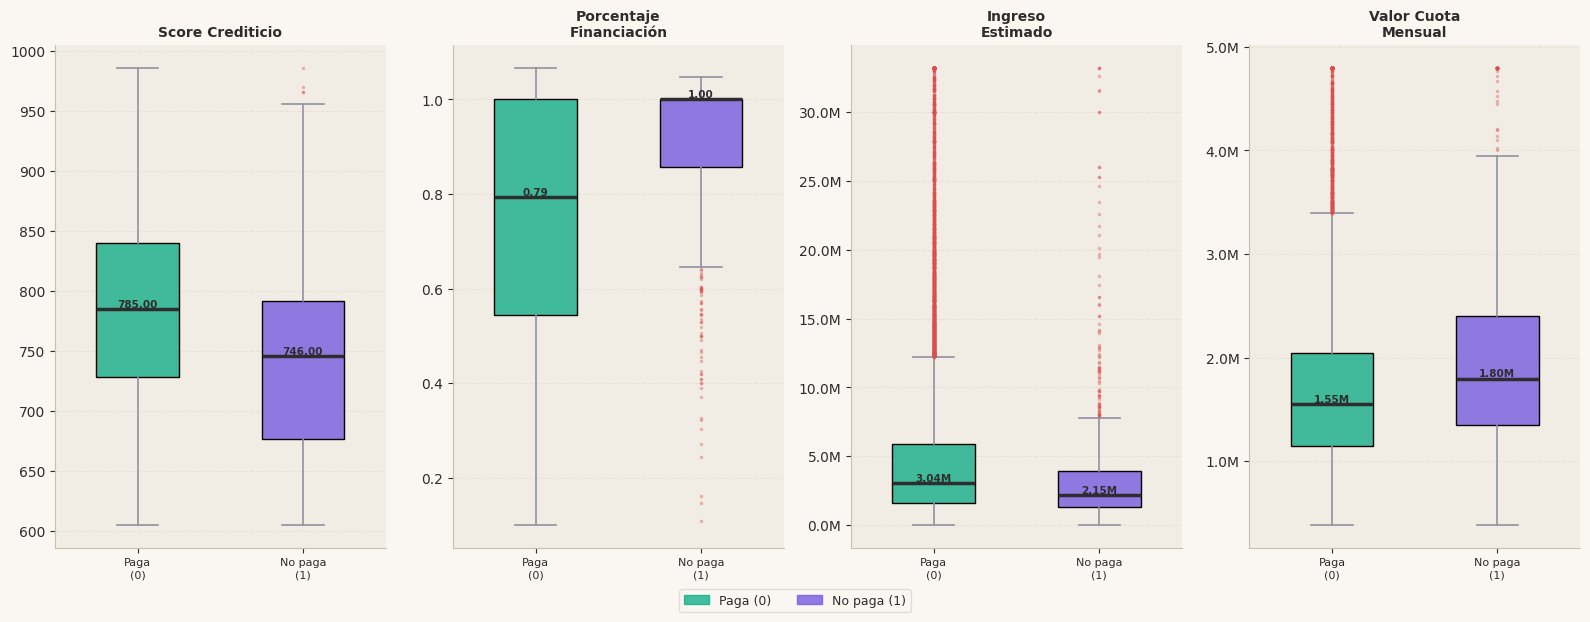

In [30]:
# ── Figura 4: Boxplots variables financieras por clase ────────────────────────
vars_box   = ['ScoreCrediticio', 'PorcentajeFinanciacion',
              'IngresoEstimado', 'ValorCuotaMensual']
labels_box = ['Score Crediticio', 'Porcentaje\nFinanciación',
              'Ingreso\nEstimado', 'Valor Cuota\nMensual']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
for i, (col, label) in enumerate(zip(vars_box, labels_box)):
    ax = axes[i]
    ax.set_facecolor(BG_AXES)
    data_0 = d0[col].dropna()
    data_1 = d1[col].dropna()

    bp = ax.boxplot([data_0, data_1], patch_artist=True, widths=0.5,
                    medianprops={'color': COLOR_TEXT, 'linewidth': 2.5},
                    whiskerprops={'color': '#9090A0', 'linewidth': 1.2},
                    capprops={'color': '#9090A0', 'linewidth': 1.2},
                    flierprops={'marker': 'o', 'markerfacecolor': COLOR_WARN,
                                'markersize': 2.5, 'alpha': 0.4,
                                'markeredgecolor': 'none'})
    bp['boxes'][0].set_facecolor(COLOR_NEG + 'BB')
    bp['boxes'][1].set_facecolor(COLOR_POS + 'BB')

    for j, datos in enumerate([data_0, data_1], 1):
        med = datos.median()
        fmt = f'{med/1e6:.2f}M' if datos.max() > 100000 else f'{med:.2f}'
        ax.text(j, med, fmt, ha='center', va='bottom',
                fontsize=7.5, color=COLOR_TEXT, fontweight='bold')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticklabels(['Paga\n(0)', 'No paga\n(1)'], fontsize=8)
    ax.grid(axis='y', alpha=0.4)

    if data_0.max() > 100000:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

patch0 = mpatches.Patch(color=COLOR_NEG+'BB', label='Paga (0)')
patch1 = mpatches.Patch(color=COLOR_POS+'BB', label='No paga (1)')
fig.legend(handles=[patch0, patch1], loc='lower center', ncol=2,
           fontsize=9, framealpha=0.6, facecolor=BG_MAIN,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('eda_04_boxplots.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 4.** Los boxplots confirman y complementan los
hallazgos del violin plot. `ScoreCrediticio` presenta la diferencia más clara
entre clases — los clientes que pagan tienen una mediana de 785 con menor
dispersión, mientras que los que no pagan tienen una mediana de 746 y una
caja intercuartílica más amplia, indicando mayor heterogeneidad dentro del
grupo en riesgo.

`PorcentajeFinanciacion` muestra la diferencia más pronunciada en términos
de posición — la mediana de los que no pagan (1.00) es considerablemente
superior a la de los que pagan (0.78), lo que confirma que financiar una
mayor proporción del bien está directamente asociado con mayor probabilidad
de incumplimiento. Adicionalmente, la clase en riesgo presenta menor
dispersión en esta variable, concentrándose en valores altos de financiación.

`IngresoEstimado` y `ValorCuotaMensual` muestran medianas similares entre
clases — 3.04M vs 2.35M en ingreso y 1.55M vs 1.80M en cuota — con
amplias cajas intercuartílicas y presencia de valores atípicos
especialmente en la clase que paga, lo que sugiere que estas variables
por sí solas tienen menor poder discriminante. En general, los boxplots
refuerzan que `ScoreCrediticio` y `PorcentajeFinanciacion` son las
variables con mayor capacidad para distinguir entre clientes que pagan
y los que no pagan.

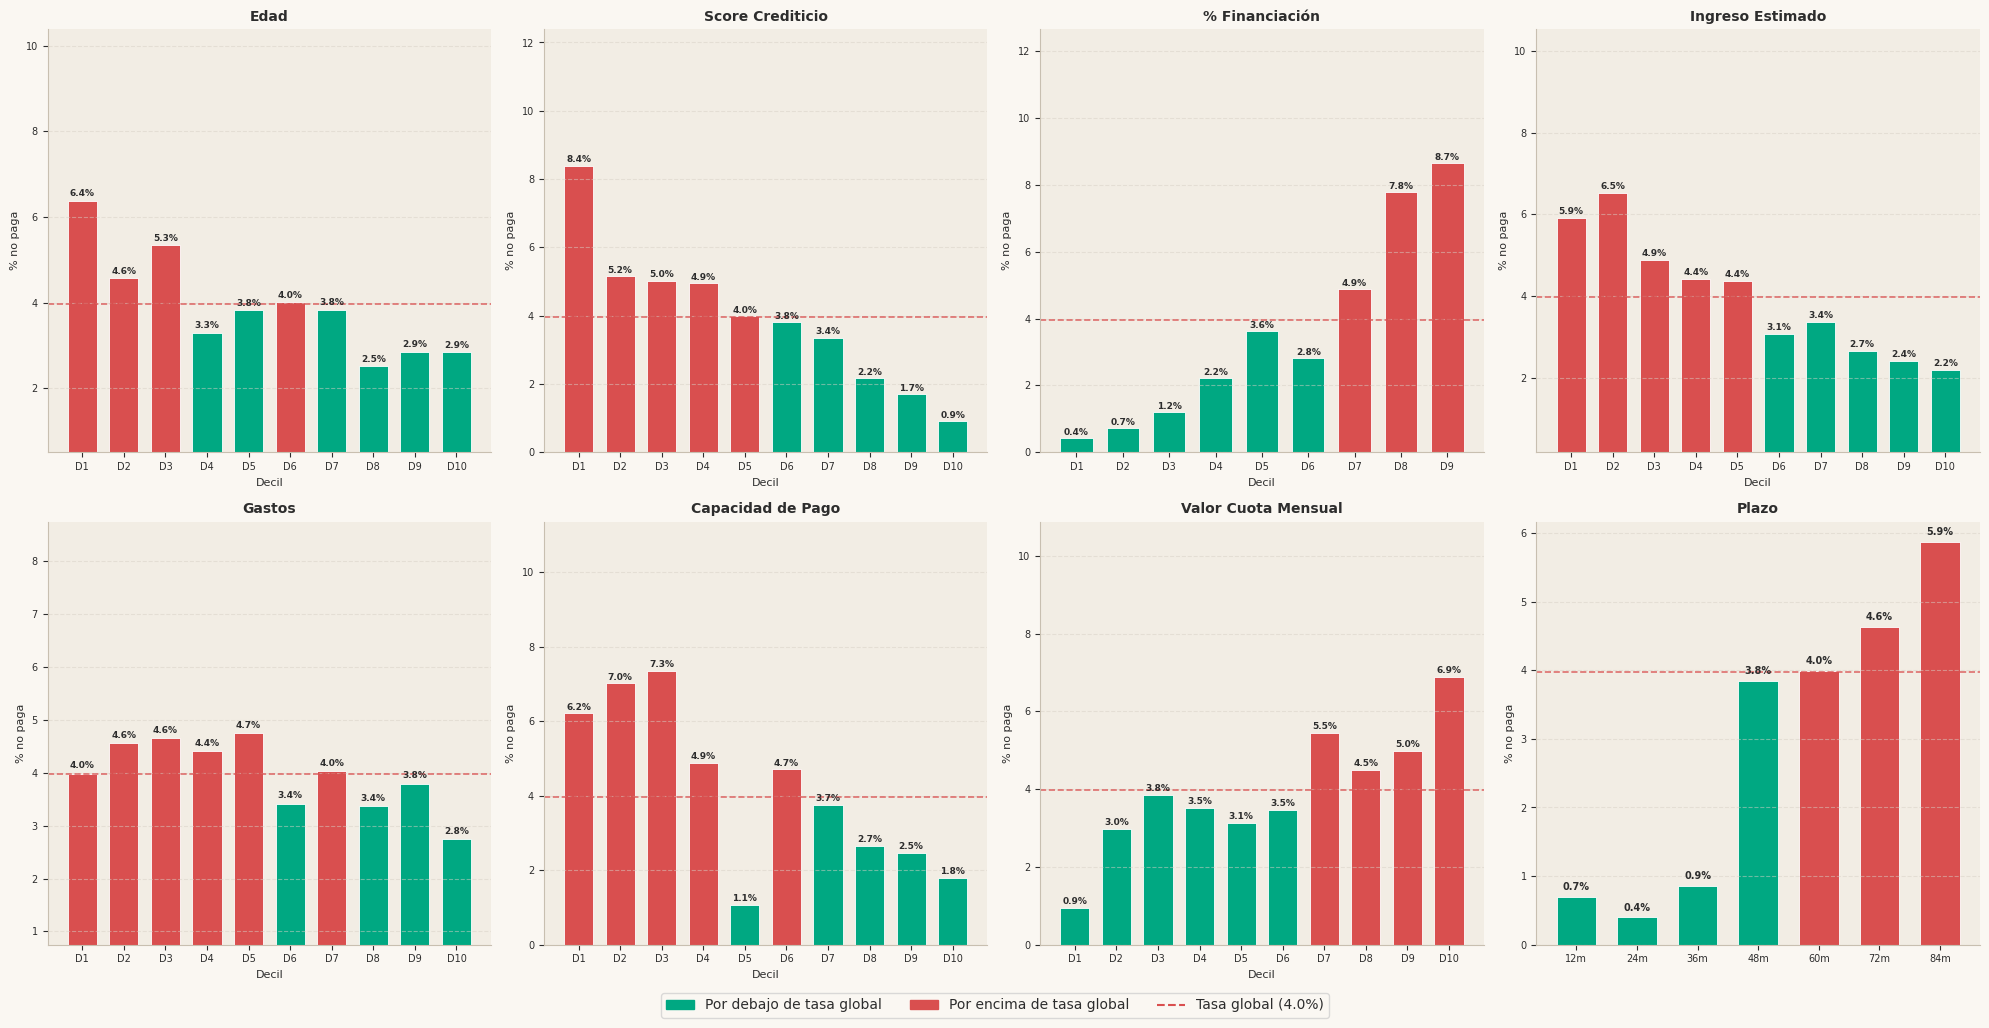

In [31]:
# ── Figura 5: Deciles por variable ────────────────────────────────────────────
from matplotlib.lines import Line2D

vars_decil = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion',
              'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
labels_dec = ['Edad', 'Score Crediticio', '% Financiación',
              'Ingreso Estimado', 'Gastos', 'Capacidad de Pago',
              'Valor Cuota Mensual']

tasa_global = (df_clean['M3_30AC'] == 1).mean() * 100

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(vars_decil, labels_dec)):
    ax = axes[i]
    ax.set_facecolor(BG_AXES)

    bins = np.unique(np.percentile(df_clean[col].dropna(),
                                    np.linspace(0, 100, 11)))
    dec_labels = [f'D{j+1}' for j in range(len(bins)-1)]
    df_clean['_dec'] = pd.cut(df_clean[col], bins=bins,
                               labels=dec_labels, include_lowest=True)

    tasa = df_clean.groupby('_dec', observed=True).apply(
        lambda x: pd.Series({
            'tasa': (x['M3_30AC']==1).sum()/len(x)*100,
            'n': len(x)
        })
    ).reset_index().dropna()

    colores_d = [COLOR_WARN if t > tasa_global else COLOR_NEG
                 for t in tasa['tasa']]
    bars = ax.bar(tasa['_dec'].astype(str), tasa['tasa'],
                  color=colores_d, edgecolor='white',
                  linewidth=0.6, width=0.7)

    for bar, row in zip(bars, tasa.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{row.tasa:.1f}%', ha='center', fontsize=6.5,
                color=COLOR_TEXT, fontweight='bold')

    ax.axhline(tasa_global, color=COLOR_WARN, linestyle='--',
               linewidth=1.2, alpha=0.8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('% no paga', fontsize=8)
    ax.set_xlabel('Decil', fontsize=8)
    ax.set_ylim(max(0, tasa['tasa'].min() - 2),
                min(104, tasa['tasa'].max() + 4))
    ax.grid(axis='y', alpha=0.5)
    ax.tick_params(labelsize=7)
    df_clean.drop(columns=['_dec'], inplace=True)

# Panel 8: Plazo
ax8 = axes[7]
ax8.set_facecolor(BG_AXES)
plazos_rep = sorted(df_clean['Plazo'].value_counts()[
    df_clean['Plazo'].value_counts() >= 100].index)
tasa_plazo = df_clean[df_clean['Plazo'].isin(plazos_rep)].groupby('Plazo').apply(
    lambda x: (x['M3_30AC']==1).sum()/len(x)*100
).reset_index()
tasa_plazo.columns = ['Plazo', 'tasa']
colores_p = [COLOR_WARN if t > tasa_global else COLOR_NEG
             for t in tasa_plazo['tasa']]
bars_p = ax8.bar(tasa_plazo['Plazo'].astype(str)+'m',
                 tasa_plazo['tasa'],
                 color=colores_p, edgecolor='white',
                 linewidth=0.6, width=0.65)
for bar, row in zip(bars_p, tasa_plazo.itertuples()):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{row.tasa:.1f}%', ha='center', fontsize=7,
             color=COLOR_TEXT, fontweight='bold')
ax8.axhline(tasa_global, color=COLOR_WARN, linestyle='--',
            linewidth=1.2, alpha=0.8)
ax8.set_title('Plazo', fontsize=10, fontweight='bold')
ax8.set_ylabel('% no paga', fontsize=8)
ax8.grid(axis='y', alpha=0.5)
ax8.tick_params(labelsize=7)

patch_bajo = mpatches.Patch(color=COLOR_NEG,  label='Por debajo de tasa global')
patch_alto = mpatches.Patch(color=COLOR_WARN, label='Por encima de tasa global')
linea_ref  = Line2D([0], [0], color=COLOR_WARN, linestyle='--', linewidth=1.5)
fig.legend(handles=[patch_bajo, patch_alto, linea_ref],
           labels=['Por debajo de tasa global', 'Por encima de tasa global',
                   f'Tasa global ({tasa_global:.1f}%)'],
           loc='lower center', ncol=3, fontsize=10,
           framealpha=0.7, facecolor=BG_MAIN,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('eda_05_deciles.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 5.** El análisis por deciles permite identificar qué
variables presentan una relación sostenida con el riesgo de no pago. La tasa
global de incumplimiento es del 4.0%, línea de referencia sobre la cual se
evalúa el comportamiento de cada decil.

`ScoreCrediticio` muestra el patrón más claro y consistente — los deciles con
scores más bajos (D1, D2) superan significativamente la tasa global con valores
cercanos al 8-9%, mientras que los deciles altos caen por debajo del 2%,
confirmando que un mejor historial crediticio reduce sustancialmente el riesgo
de incumplimiento.

`PorcentajeFinanciacion` presenta una tendencia creciente clara — los deciles
de mayor financiación (D8, D9, D10) concentran las tasas más altas de no pago
superando el 7-8%, mientras que los deciles bajos se mantienen por debajo de
la tasa global. Esto refuerza que financiar una mayor proporción del bien
incrementa el riesgo de manera progresiva.

`Edad` muestra una tendencia decreciente moderada — los clientes más jóvenes
(D1, D2) presentan mayor tasa de incumplimiento, mientras que los de mayor
edad tienden a cumplir mejor. `ValorCuotaMensual` y `CapacidadDePago` presentan
patrones irregulares sin una tendencia clara entre deciles, confirmando su
limitado poder predictivo individual.

`Gastos` e `IngresoEstimado` muestran comportamientos mixtos sin tendencia
definida. En `Plazo`, los créditos de mayor duración (72 y 84 meses) presentan
las tasas más altas de no pago con 4.6% y 5.9% respectivamente, superando la
tasa global. En síntesis, `ScoreCrediticio`, `PorcentajeFinanciacion` y `Plazo`
son las variables con mayor potencial discriminante para el modelo.

### Analisis EDA para el nuevo dataset

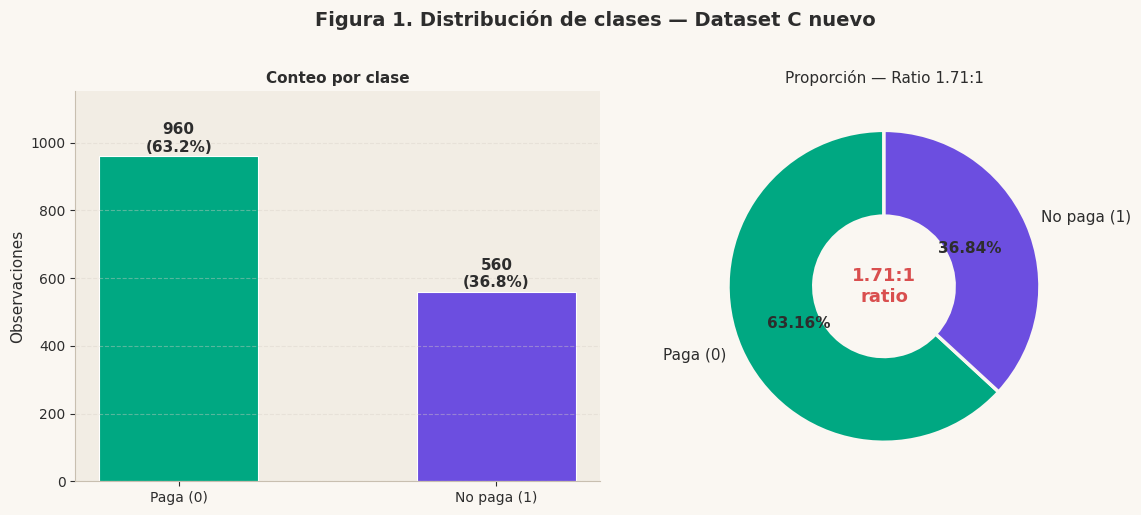

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# EDA — DATASET C NUEVO
# ═══════════════════════════════════════════════════════════════════════════════

d0_cn = train_cn_final[train_cn_final['M3_30AC'] == 0]
d1_cn = train_cn_final[train_cn_final['M3_30AC'] == 1]

# ── Figura 1: Distribución de clases ─────────────────────────────────────────
conteo_cn = train_cn_final['M3_30AC'].value_counts()
total_cn  = len(train_cn_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figura 1. Distribución de clases — Dataset C nuevo',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.02)

# Barplot
ax = axes[0]
ax.set_facecolor(BG_AXES)
bars = ax.bar(['Paga (0)', 'No paga (1)'],
              [conteo_cn[0], conteo_cn[1]],
              color=[COLOR_NEG, COLOR_POS],
              width=0.5, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, [conteo_cn[0], conteo_cn[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}\n({val/total_cn*100:.1f}%)',
            ha='center', va='bottom', fontsize=11,
            color=COLOR_TEXT, fontweight='bold')
ax.set_title('Conteo por clase', fontsize=11, fontweight='bold')
ax.set_ylabel('Observaciones')
ax.set_ylim(0, conteo_cn[0] * 1.2)
ax.grid(axis='y', alpha=0.4)

# Donut
ax2 = axes[1]
ax2.set_facecolor(BG_AXES)
ratio_cn = conteo_cn[0] / conteo_cn[1]
wedges, texts, autotexts = ax2.pie(
    [conteo_cn[0], conteo_cn[1]],
    labels=['Paga (0)', 'No paga (1)'],
    autopct='%1.2f%%',
    colors=[COLOR_NEG, COLOR_POS],
    startangle=90,
    wedgeprops={'edgecolor': BG_MAIN, 'linewidth': 2.5, 'width': 0.55},
    textprops={'color': COLOR_TEXT, 'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_facecolor(BG_AXES)
ax2.set_title(f'Proporción — Ratio {ratio_cn:.2f}:1', fontsize=11)
ax2.text(0, 0, f'{ratio_cn:.2f}:1\nratio', ha='center', va='center',
         fontsize=13, color=COLOR_WARN, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_cn_01_clases.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

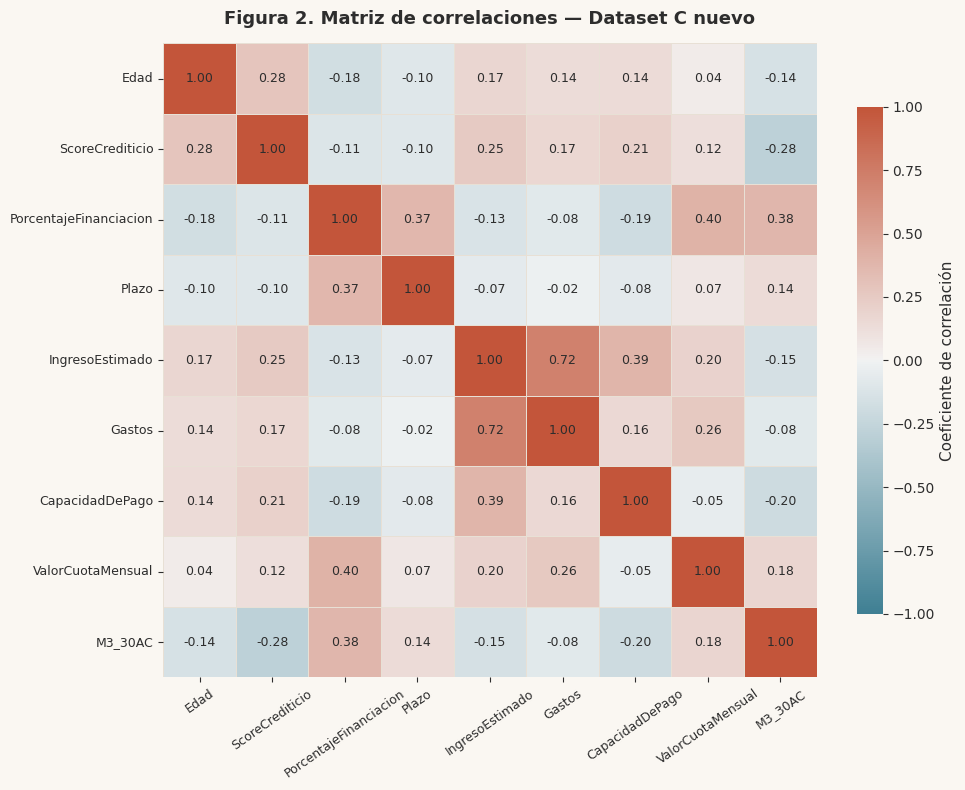

In [ ]:
# ── Figura 2: Matriz de correlaciones — completa ──────────────────────────────
vars_num_cn = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
               'IngresoEstimado', 'Gastos', 'CapacidadDePago',
               'ValorCuotaMensual', 'M3_30AC']

corr_cn = train_cn_final[vars_num_cn].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG_MAIN)
ax.set_facecolor(BG_AXES)

cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr_cn, ax=ax, cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9, 'color': COLOR_TEXT},
    linewidths=0.5, linecolor='#E8E0D5',
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'}
)

ax.set_title('Figura 2. Matriz de correlaciones — Dataset C nuevo',
             fontsize=13, fontweight='bold', color=COLOR_TEXT, pad=14)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('eda_cn_02_correlaciones.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

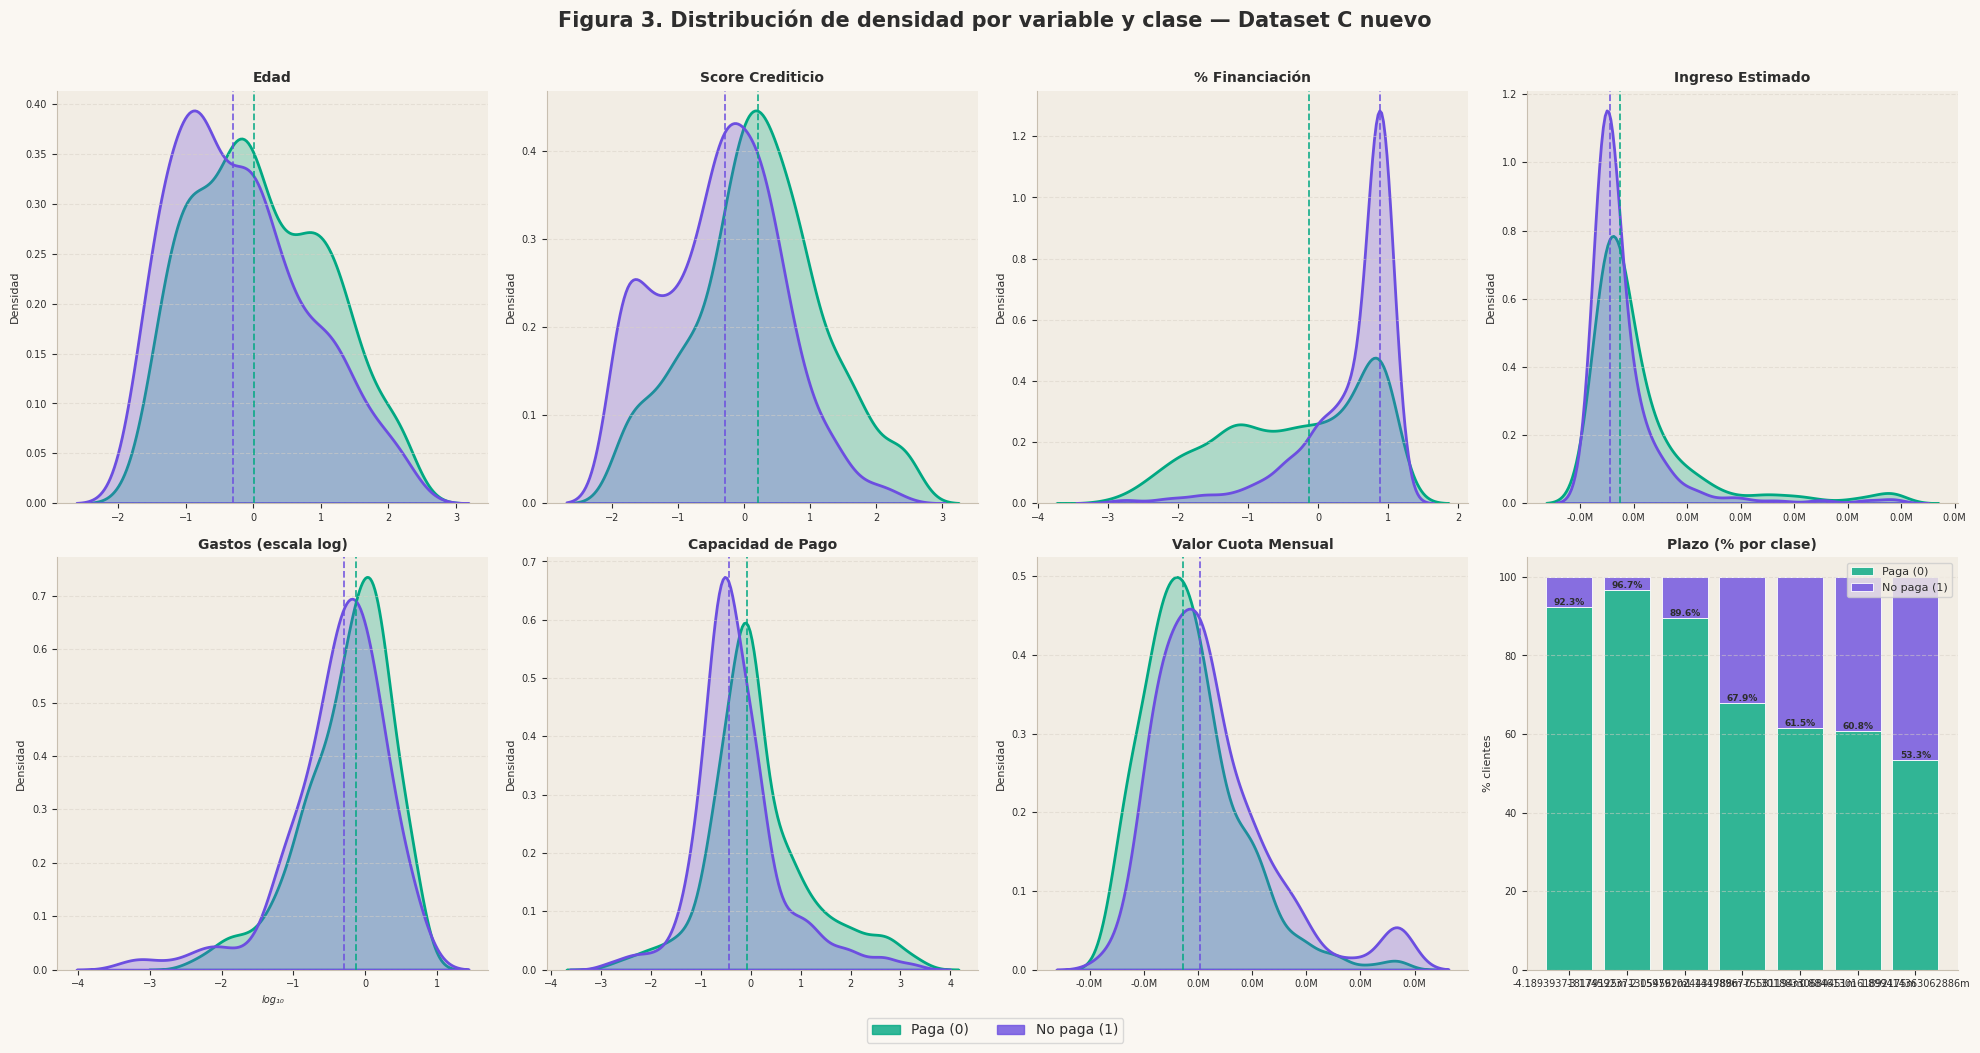

In [ ]:
# ── Figura 3: Distribución de densidad por variable y clase ───────────────────
vars_config_cn = [
    ('Edad',                  'Edad',                False),
    ('ScoreCrediticio',       'Score Crediticio',     False),
    ('PorcentajeFinanciacion','% Financiación',       False),
    ('IngresoEstimado',       'Ingreso Estimado',     False),
    ('Gastos',                'Gastos (escala log)',  True),
    ('CapacidadDePago',       'Capacidad de Pago',    False),
    ('ValorCuotaMensual',     'Valor Cuota Mensual',  False),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('Figura 3. Distribución de densidad por variable y clase — Dataset C nuevo',
             fontsize=15, fontweight='bold', color=COLOR_TEXT, y=1.01)

for i, (col, label, usar_log) in enumerate(vars_config_cn):
    ax = axes[i]
    ax.set_facecolor(BG_AXES)

    data0 = np.log10(d0_cn[col].dropna()) if usar_log else d0_cn[col].dropna()
    data1 = np.log10(d1_cn[col].dropna()) if usar_log else d1_cn[col].dropna()

    sns.kdeplot(data0, ax=ax, color=COLOR_NEG, linewidth=2,
                fill=True, alpha=0.28, label='Paga (0)')
    sns.kdeplot(data1, ax=ax, color=COLOR_POS, linewidth=2,
                fill=True, alpha=0.28, label='No paga (1)')

    for datos, color in [(data0, COLOR_NEG), (data1, COLOR_POS)]:
        ax.axvline(datos.median(), color=color, linestyle='--',
                   linewidth=1.3, alpha=0.85)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Densidad', fontsize=8)
    ax.set_xlabel('log₁₀' if usar_log else '', fontsize=7, style='italic')
    ax.grid(axis='y', alpha=0.5)
    ax.tick_params(labelsize=7)

    vars_millones = ['IngresoEstimado', 'ValorCuotaMensual']
    if not usar_log and col in vars_millones:
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Panel 8: Plazo como barras apiladas
ax8 = axes[7]
ax8.set_facecolor(BG_AXES)
plazos_rep = sorted(train_cn_final['Plazo'].value_counts()[
    train_cn_final['Plazo'].value_counts() >= 10].index)
df_p = train_cn_final[train_cn_final['Plazo'].isin(plazos_rep)]
tasa_p = df_p.groupby('Plazo').apply(
    lambda x: pd.Series({
        'pct_0': (x['M3_30AC']==0).sum()/len(x)*100,
        'pct_1': (x['M3_30AC']==1).sum()/len(x)*100,
    })
).reset_index()
x_pos = np.arange(len(tasa_p))
ax8.bar(x_pos, tasa_p['pct_0'], color=COLOR_NEG+'CC',
        edgecolor='white', linewidth=0.6, label='Paga (0)')
ax8.bar(x_pos, tasa_p['pct_1'], bottom=tasa_p['pct_0'],
        color=COLOR_POS+'CC', edgecolor='white', linewidth=0.6,
        label='No paga (1)')
ax8.set_xticks(x_pos)
ax8.set_xticklabels([f'{p}m' for p in tasa_p['Plazo']], fontsize=7.5)
for idx_b, row in tasa_p.iterrows():
    ax8.text(idx_b, row['pct_0'] + 0.5, f"{row['pct_0']:.1f}%",
             ha='center', fontsize=6.5, color=COLOR_TEXT, fontweight='bold')
ax8.set_title('Plazo (% por clase)', fontsize=10, fontweight='bold')
ax8.set_ylabel('% clientes', fontsize=8)
ax8.set_ylim(0, 105)
ax8.grid(axis='y', alpha=0.5)
ax8.tick_params(labelsize=7)
ax8.legend(fontsize=8)

patch0 = mpatches.Patch(color=COLOR_NEG+'CC', label='Paga (0)')
patch1 = mpatches.Patch(color=COLOR_POS+'CC', label='No paga (1)')
fig.legend(handles=[patch0, patch1], loc='lower center', ncol=2,
           fontsize=10, framealpha=0.7, facecolor=BG_MAIN,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('eda_cn_03_densidad.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 3.** La distribución de densidad por variable y clase
revela diferencias moderadas entre clientes que pagan (clase 0) y los que no
pagan (clase 1). En `Edad`, los clientes que no pagan tienden a ser más jóvenes,
con una distribución desplazada hacia la izquierda respecto a los que sí pagan.
El `ScoreCrediticio` muestra la diferencia más clara entre clases — los clientes
en riesgo presentan scores más bajos, lo que confirma su capacidad discriminante
identificada en el EDA original. En `PorcentajeFinanciacion` la clase en riesgo
concentra más observaciones en valores altos de financiación, coherente con lo
observado anteriormente. Variables como `Gastos`, `CapacidadDePago` y
`ValorCuotaMensual` muestran distribuciones muy similares entre clases con
medianas cercanas, lo que sugiere menor poder discriminante individual. En el
panel de `Plazo`, se evidencia que los créditos de mayor duración concentran
una proporción más alta de clientes que no pagan, siendo el plazo de 84 meses
el que presenta mayor riesgo con apenas el 52.3% de clientes que pagan. En
general, las distribuciones son más similares entre clases que en el dataset
original, lo cual es esperado dado que el balanceo redujo el dominio de la
clase mayoritaria.

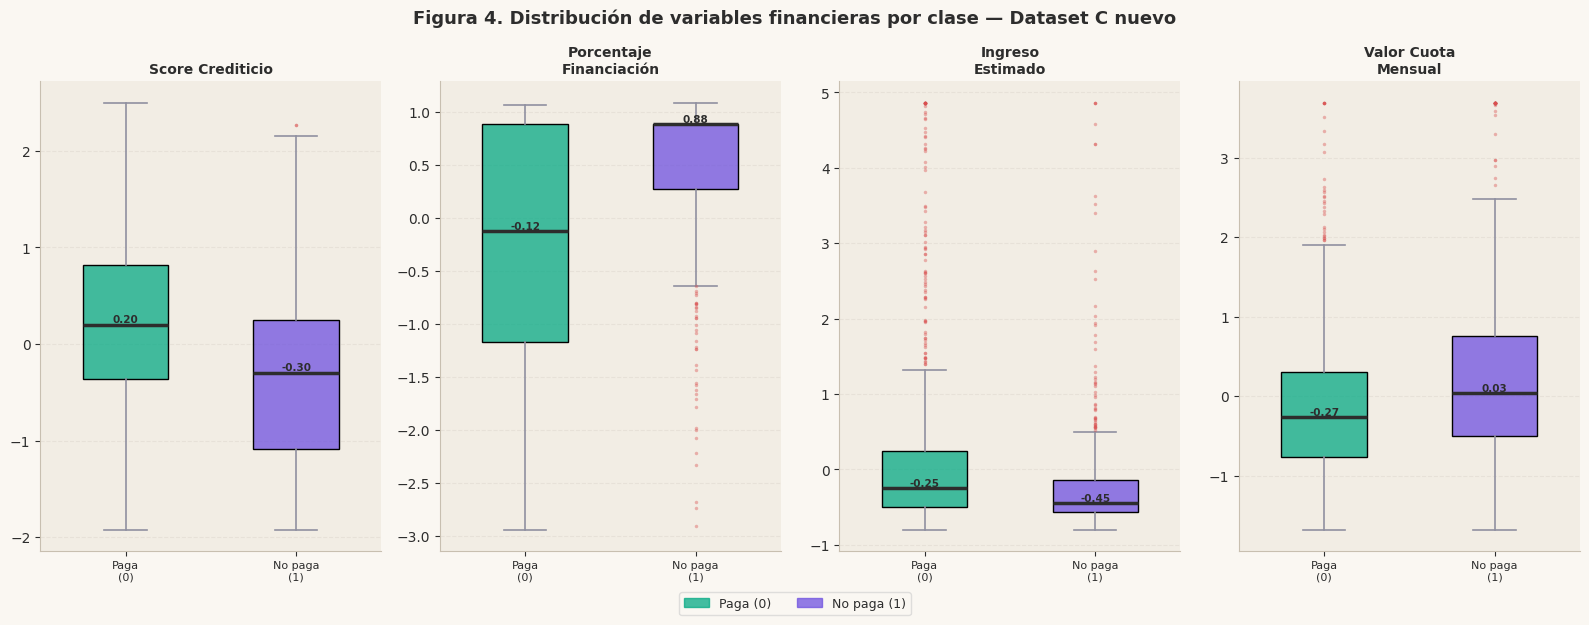

In [ ]:
# ── Figura 4: Boxplots variables financieras por clase ────────────────────────
vars_box_cn   = ['ScoreCrediticio', 'PorcentajeFinanciacion',
                 'IngresoEstimado', 'ValorCuotaMensual']
labels_box_cn = ['Score Crediticio', 'Porcentaje\nFinanciación',
                 'Ingreso\nEstimado', 'Valor Cuota\nMensual']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle('Figura 4. Distribución de variables financieras por clase — Dataset C nuevo',
             fontsize=13, fontweight='bold', color=COLOR_TEXT)

for i, (col, label) in enumerate(zip(vars_box_cn, labels_box_cn)):
    ax = axes[i]
    ax.set_facecolor(BG_AXES)
    data_0 = d0_cn[col].dropna()
    data_1 = d1_cn[col].dropna()

    bp = ax.boxplot([data_0, data_1], patch_artist=True, widths=0.5,
                    medianprops={'color': COLOR_TEXT, 'linewidth': 2.5},
                    whiskerprops={'color': '#9090A0', 'linewidth': 1.2},
                    capprops={'color': '#9090A0', 'linewidth': 1.2},
                    flierprops={'marker': 'o', 'markerfacecolor': COLOR_WARN,
                                'markersize': 2.5, 'alpha': 0.4,
                                'markeredgecolor': 'none'})
    bp['boxes'][0].set_facecolor(COLOR_NEG + 'BB')
    bp['boxes'][1].set_facecolor(COLOR_POS + 'BB')

    for j, datos in enumerate([data_0, data_1], 1):
        med = datos.median()
        fmt = f'{med/1e6:.2f}M' if datos.max() > 100000 else f'{med:.2f}'
        ax.text(j, med, fmt, ha='center', va='bottom',
                fontsize=7.5, color=COLOR_TEXT, fontweight='bold')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticklabels(['Paga\n(0)', 'No paga\n(1)'], fontsize=8)
    ax.grid(axis='y', alpha=0.4)

    if data_0.max() > 100000:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

patch0 = mpatches.Patch(color=COLOR_NEG+'BB', label='Paga (0)')
patch1 = mpatches.Patch(color=COLOR_POS+'BB', label='No paga (1)')
fig.legend(handles=[patch0, patch1], loc='lower center', ncol=2,
           fontsize=9, framealpha=0.6, facecolor=BG_MAIN,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('eda_cn_04_boxplots.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 4.** Los boxplots revelan diferencias entre clases
principalmente en `ScoreCrediticio` y `PorcentajeFinanciacion`. En el score
crediticio, los clientes que pagan presentan una mediana superior (0.20) frente
a los que no pagan (-0.30), confirmando que un mejor historial crediticio está
asociado con menor riesgo de incumplimiento. En `PorcentajeFinanciacion` la
diferencia es notable — los clientes en riesgo tienen una mediana de 0.88
frente a -0.12 de los que pagan, lo que indica que financiar una mayor
proporción del bien incrementa la probabilidad de no pago. En contraste,
`IngresoEstimado` y `ValorCuotaMensual` muestran distribuciones muy similares
entre clases, con medianas cercanas y amplia dispersión en ambos grupos,
sugiriendo que estas variables por sí solas tienen menor capacidad discriminante.
La presencia de valores atípicos en todas las variables es más pronunciada en
la clase de riesgo, lo que indica mayor heterogeneidad financiera entre los
clientes que no pagan.

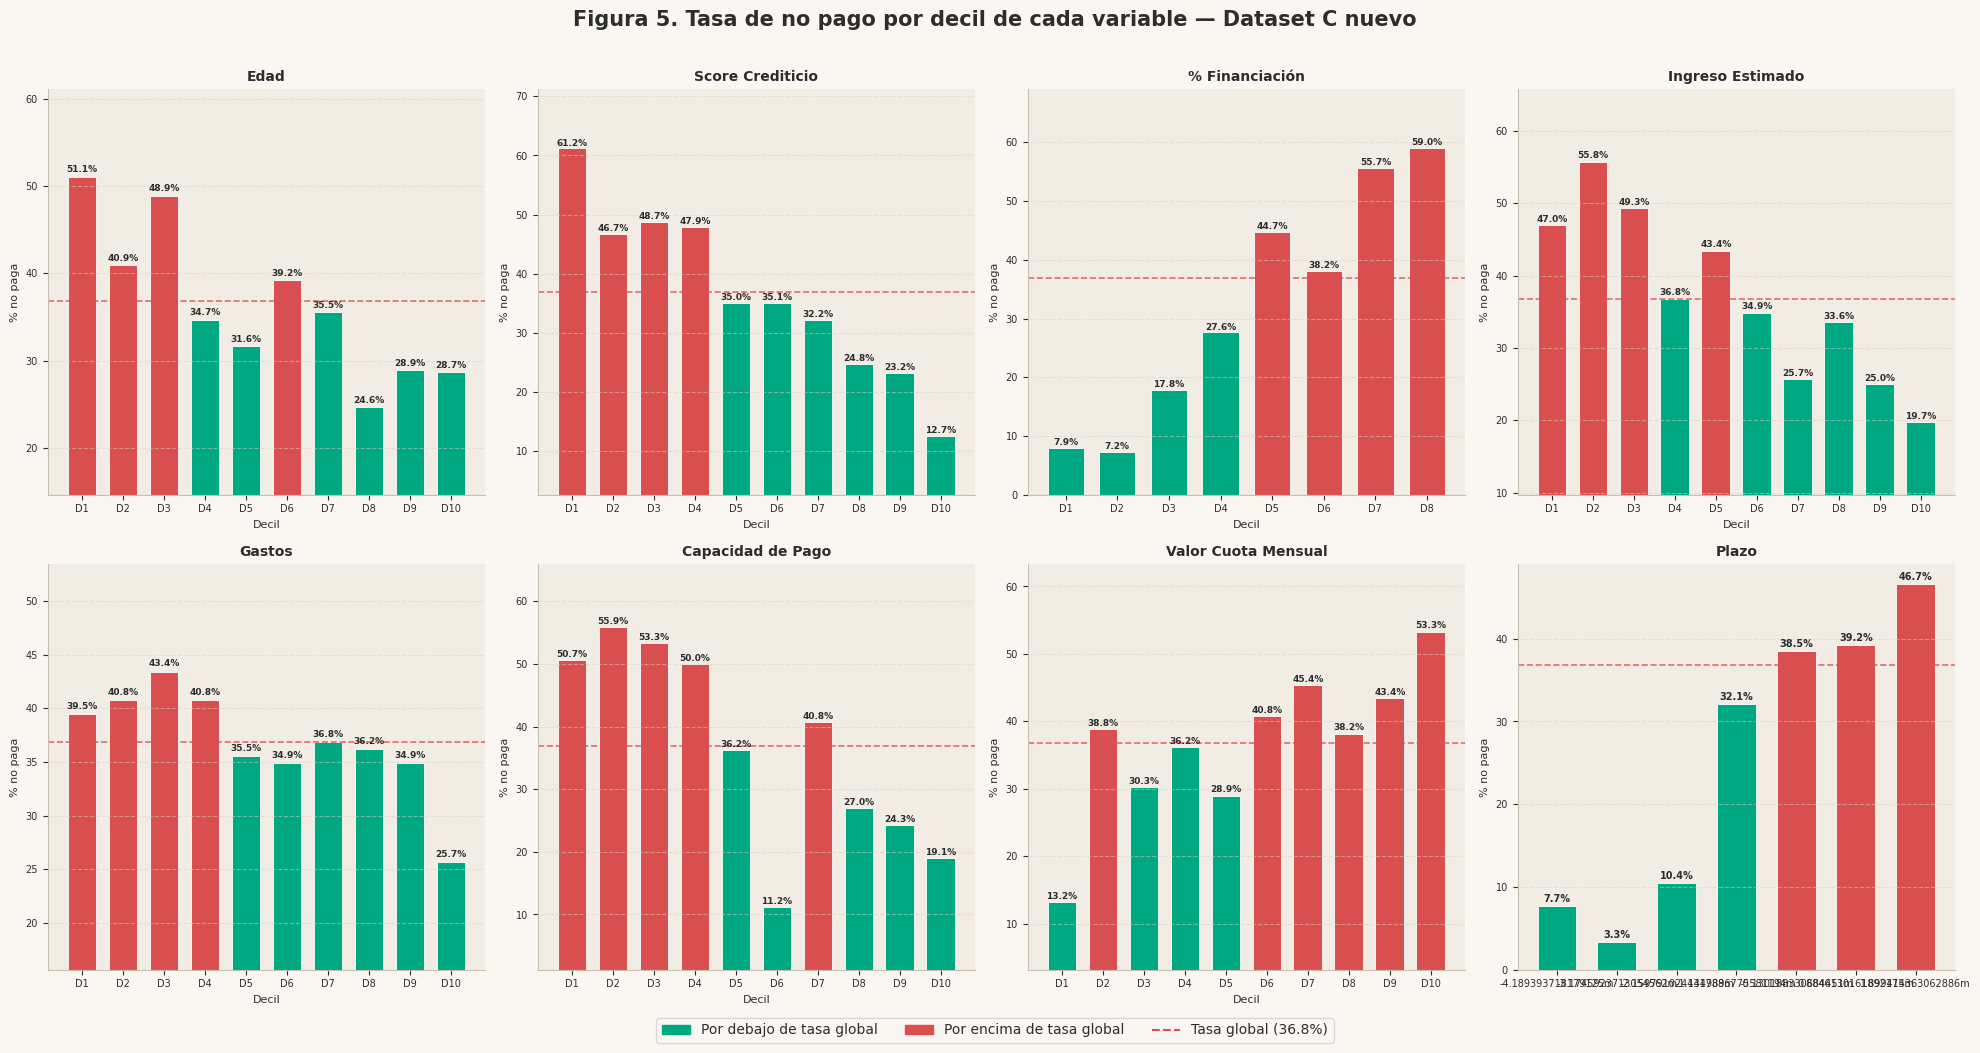

In [ ]:
# ── Figura 5: Deciles por variable ────────────────────────────────────────────
from matplotlib.lines import Line2D

vars_decil_cn = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion',
                 'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
labels_dec_cn = ['Edad', 'Score Crediticio', '% Financiación',
                 'Ingreso Estimado', 'Gastos', 'Capacidad de Pago',
                 'Valor Cuota Mensual']

tasa_global_cn = (train_cn_final['M3_30AC'] == 1).mean() * 100

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('Figura 5. Tasa de no pago por decil de cada variable — Dataset C nuevo',
             fontsize=15, fontweight='bold', color=COLOR_TEXT, y=1.01)

for i, (col, label) in enumerate(zip(vars_decil_cn, labels_dec_cn)):
    ax = axes[i]
    ax.set_facecolor(BG_AXES)

    bins = np.unique(np.percentile(
        train_cn_final[col].dropna(), np.linspace(0, 100, 11)))
    dec_labels = [f'D{j+1}' for j in range(len(bins)-1)]
    train_cn_final['_dec'] = pd.cut(train_cn_final[col],
                                     bins=bins, labels=dec_labels,
                                     include_lowest=True)

    tasa = train_cn_final.groupby('_dec', observed=True).apply(
        lambda x: pd.Series({
            'tasa': (x['M3_30AC']==1).sum()/len(x)*100,
            'n': len(x)
        })
    ).reset_index().dropna()

    colores_d = [COLOR_WARN if t > tasa_global_cn else COLOR_NEG
                 for t in tasa['tasa']]
    bars = ax.bar(tasa['_dec'].astype(str), tasa['tasa'],
                  color=colores_d, edgecolor='white',
                  linewidth=0.6, width=0.7)

    for bar, row in zip(bars, tasa.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{row.tasa:.1f}%', ha='center', fontsize=6.5,
                color=COLOR_TEXT, fontweight='bold')

    ax.axhline(tasa_global_cn, color=COLOR_WARN, linestyle='--',
               linewidth=1.2, alpha=0.8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('% no paga', fontsize=8)
    ax.set_xlabel('Decil', fontsize=8)
    ax.set_ylim(max(0, tasa['tasa'].min() - 10),
                min(104, tasa['tasa'].max() + 10))
    ax.grid(axis='y', alpha=0.5)
    ax.tick_params(labelsize=7)
    train_cn_final.drop(columns=['_dec'], inplace=True)

# Panel 8: Plazo
ax8 = axes[7]
ax8.set_facecolor(BG_AXES)
plazos_rep = sorted(train_cn_final['Plazo'].value_counts()[
    train_cn_final['Plazo'].value_counts() >= 10].index)
tasa_plazo = train_cn_final[train_cn_final['Plazo'].isin(plazos_rep)].groupby('Plazo').apply(
    lambda x: (x['M3_30AC']==1).sum()/len(x)*100
).reset_index()
tasa_plazo.columns = ['Plazo', 'tasa']
colores_p = [COLOR_WARN if t > tasa_global_cn else COLOR_NEG
             for t in tasa_plazo['tasa']]
bars_p = ax8.bar(tasa_plazo['Plazo'].astype(str)+'m',
                 tasa_plazo['tasa'],
                 color=colores_p, edgecolor='white',
                 linewidth=0.6, width=0.65)
for bar, row in zip(bars_p, tasa_plazo.itertuples()):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{row.tasa:.1f}%', ha='center', fontsize=7,
             color=COLOR_TEXT, fontweight='bold')
ax8.axhline(tasa_global_cn, color=COLOR_WARN, linestyle='--',
            linewidth=1.2, alpha=0.8)
ax8.set_title('Plazo', fontsize=10, fontweight='bold')
ax8.set_ylabel('% no paga', fontsize=8)
ax8.grid(axis='y', alpha=0.5)
ax8.tick_params(labelsize=7)

patch_bajo = mpatches.Patch(color=COLOR_NEG,  label='Por debajo de tasa global')
patch_alto = mpatches.Patch(color=COLOR_WARN, label='Por encima de tasa global')
linea_ref  = Line2D([0], [0], color=COLOR_WARN, linestyle='--', linewidth=1.5)
fig.legend(handles=[patch_bajo, patch_alto, linea_ref],
           labels=['Por debajo de tasa global', 'Por encima de tasa global',
                   f'Tasa global ({tasa_global_cn:.1f}%)'],
           loc='lower center', ncol=3, fontsize=10,
           framealpha=0.7, facecolor=BG_MAIN,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('eda_cn_05_deciles.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

**Interpretación — Figura 5.** El análisis por deciles permite identificar qué
variables presentan una relación sistemática con el riesgo de no pago en el
Dataset C nuevo. La tasa global de no pago es del 36.8%, línea de referencia
sobre la cual se evalúa cada decil.

`ScoreCrediticio` muestra la tendencia más constante — los deciles
con scores más bajos (D1, D2) concentran tasas de no pago superiores al 60%,
mientras que los deciles altos caen por debajo del 15%. Esta relación inversa
confirma que el score crediticio es la variable con mayor capacidad
discriminante del dataset.

`PorcentajeFinanciacion` presenta una tendencia creciente consistente — a
mayor porcentaje financiado, mayor probabilidad de no pago, con los deciles
superiores superando el 55% de tasa de incumplimiento. Esto refuerza su
relevancia como predictor de riesgo.

`Edad` muestra una tendencia decreciente moderada — los clientes más jóvenes
(D1, D2) presentan tasas de no pago superiores al 50%, mientras que los de
mayor edad tienden a cumplir mejor con sus obligaciones.

`CapacidadDePago` y `ValorCuotaMensual` presentan patrones menos monotónicos
con mayor variabilidad entre deciles, lo que sugiere menor capacidad
discriminante individual aunque pueden aportar valor en combinación con otras
variables dentro del modelo.

`Gastos` e `IngresoEstimado` muestran comportamientos irregulares sin una
tendencia clara, confirmando su limitado poder predictivo de forma aislada.
En `Plazo`, los créditos de mayor duración concentran tasas de no pago
significativamente más altas, siendo el plazo más largo el de mayor riesgo
con 46.7% de incumplimiento.

## **Fase 2. Entrenamiento de red red neuronal**

### Modelo base


In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# FASE 3 — MODELO BASE — Dataset C nuevo
# Sin dropout — arquitectura básica de referencia
# ═══════════════════════════════════════════════════════════════════════════════

# ── Preparar datos ────────────────────────────────────────────────────────────
X_tr = X_tr_cn
y_tr = y_tr_cn
X_te = X_te_cn
y_te = y_te_cn

print(f'Train : {X_tr.shape}')
print(f'  Clase 0 (paga)    : {(y_tr==0).sum():,}')
print(f'  Clase 1 (no paga) : {(y_tr==1).sum():,}')
print(f'Test  : {X_te.shape}')
print(f'  Clase 0 (paga)    : {(y_te==0).sum():,}')
print(f'  Clase 1 (no paga) : {(y_te==1).sum():,}')

# ── Arquitectura básica — sin dropout ─────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

modelo_base_cn = Sequential()
modelo_base_cn.add(InputLayer(shape=(X_tr.shape[1],)))
modelo_base_cn.add(Dense(64, activation='relu'))
modelo_base_cn.add(Dense(32, activation='relu'))
modelo_base_cn.add(Dense(1,  activation='sigmoid'))

modelo_base_cn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy',
             keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.AUC(name='auc')]
)

modelo_base_cn.summary()

Train : (1520, 11)
  Clase 0 (paga)    : 960
  Clase 1 (no paga) : 560
Test  : (380, 11)
  Clase 0 (paga)    : 240
  Clase 1 (no paga) : 140


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)


 Modelo base entrenado.
   Épocas        : 24
   Mejor época   : 9


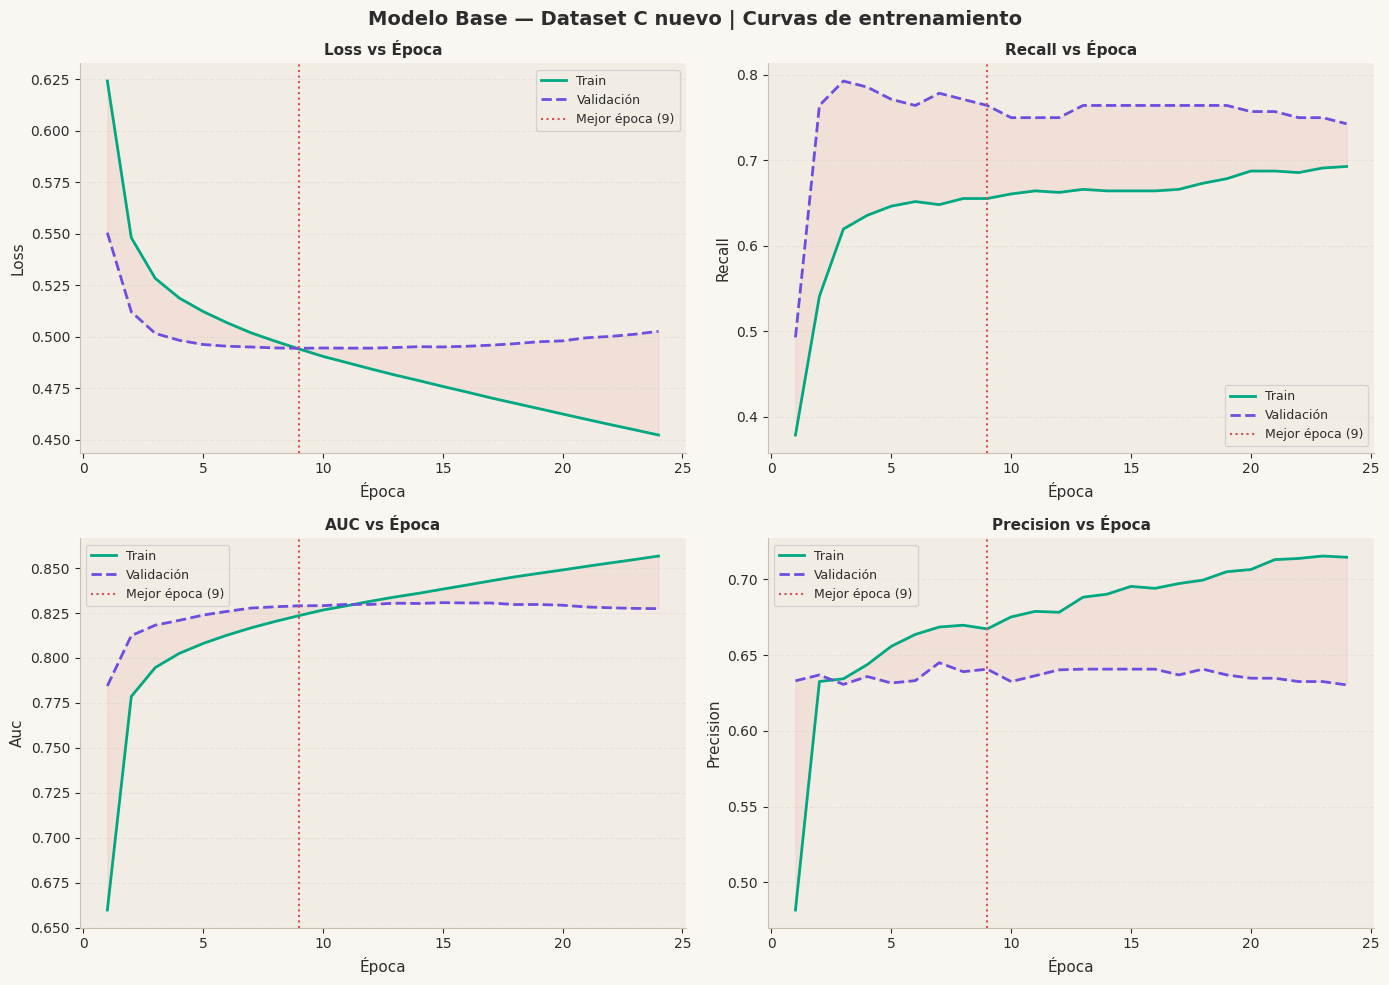

  MODELO BASE — TRAIN
              precision    recall  f1-score   support

    Paga (0)     0.8262    0.7823    0.8036       960
 No paga (1)     0.6579    0.7179    0.6866       560

    accuracy                         0.7586      1520
   macro avg     0.7421    0.7501    0.7451      1520
weighted avg     0.7642    0.7586    0.7605      1520

  MODELO BASE — TEST
              precision    recall  f1-score   support

    Paga (0)     0.8451    0.7500    0.7947       240
 No paga (1)     0.6407    0.7643    0.6971       140

    accuracy                         0.7553       380
   macro avg     0.7429    0.7571    0.7459       380
weighted avg     0.7698    0.7553    0.7587       380

  AUC-ROC : 0.8287


In [34]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
callback_base_cn = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

historia_base_cn = modelo_base_cn.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=150,
    batch_size=32,
    callbacks=[callback_base_cn],
    verbose=0
)

print(f'\n Modelo base entrenado.')
print(f'   Épocas        : {len(historia_base_cn.history["loss"])}')
print(f'   Mejor época   : {np.argmin(historia_base_cn.history["val_loss"]) + 1}')

# ── Figura completa — curvas de entrenamiento ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modelo Base — Dataset C nuevo | Curvas de entrenamiento',
             fontsize=14, fontweight='bold', color=COLOR_TEXT)

epocas      = range(1, len(historia_base_cn.history['loss']) + 1)
mejor_epoca = np.argmin(historia_base_cn.history['val_loss'])

for ax, metrica, titulo in [
    (axes[0][0], 'loss',      'Loss vs Época'),
    (axes[0][1], 'recall',    'Recall vs Época'),
    (axes[1][0], 'auc',       'AUC vs Época'),
    (axes[1][1], 'precision', 'Precision vs Época'),
]:
    ax.set_facecolor(BG_AXES)
    ax.plot(epocas, historia_base_cn.history[metrica],
            color=COLOR_NEG, linewidth=2, label='Train')
    ax.plot(epocas, historia_base_cn.history[f'val_{metrica}'],
            color=COLOR_POS, linewidth=2, linestyle='--', label='Validación')
    ax.axvline(mejor_epoca + 1, color=COLOR_WARN, linestyle=':',
               linewidth=1.5, label=f'Mejor época ({mejor_epoca + 1})')
    ax.fill_between(epocas,
                    historia_base_cn.history[metrica],
                    historia_base_cn.history[f'val_{metrica}'],
                    alpha=0.08, color=COLOR_WARN)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel(metrica.capitalize())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('modelo_base_cn_curvas.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

# ── Métricas train y test ─────────────────────────────────────────────────────
y_pred_prob_base_cn       = modelo_base_cn.predict(X_te, verbose=0).flatten()
y_pred_prob_base_cn_train = modelo_base_cn.predict(X_tr, verbose=0).flatten()
y_pred_base_cn            = (y_pred_prob_base_cn       >= 0.5).astype(int)
y_pred_base_cn_train      = (y_pred_prob_base_cn_train >= 0.5).astype(int)
auc_base_cn               = roc_auc_score(y_te, y_pred_prob_base_cn)

print('=' * 58)
print('  MODELO BASE — TRAIN')
print('=' * 58)
print(classification_report(y_tr, y_pred_base_cn_train,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))

print('=' * 58)
print('  MODELO BASE — TEST')
print('=' * 58)
print(classification_report(y_te, y_pred_base_cn,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))
print(f'  AUC-ROC : {auc_base_cn:.4f}')
print('=' * 58)

### Modelo mejorando metricas

In [57]:
# ── Modelo mejorado — con dropout ─────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

modelo_v2_cn = Sequential()
modelo_v2_cn.add(InputLayer(shape=(X_tr.shape[1],)))
modelo_v2_cn.add(Dense(32, activation='relu'))
modelo_v2_cn.add(Dropout(0.2))
modelo_v2_cn.add(Dense(16, activation='relu'))
modelo_v2_cn.add(Dropout(0.1))
modelo_v2_cn.add(Dense(1, activation='sigmoid'))

modelo_v2_cn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy',
             keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.AUC(name='auc')]
)

callback_v2_cn = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

historia_v2_cn = modelo_v2_cn.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=50,
    batch_size=32,
    callbacks=[callback_v2_cn],
    verbose=1
)

print(f'\n Modelo v2 entrenado.')
print(f'   Épocas        : {len(historia_v2_cn.history["loss"])}')
print(f'   Mejor época   : {np.argmin(historia_v2_cn.history["val_loss"]) + 1}')

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4553 - auc: 0.4819 - loss: 0.7980 - precision: 0.3684 - recall: 0.6696 - val_accuracy: 0.6211 - val_auc: 0.6705 - val_loss: 0.6531 - val_precision: 0.4844 - val_recall: 0.4429
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6349 - auc: 0.6615 - loss: 0.6270 - precision: 0.5071 - recall: 0.3179 - val_accuracy: 0.7026 - val_auc: 0.7739 - val_loss: 0.5768 - val_precision: 0.7143 - val_recall: 0.3214
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6592 - auc: 0.7274 - loss: 0.5856 - precision: 0.5882 - recall: 0.2500 - val_accuracy: 0.7211 - val_auc: 0.7977 - val_loss: 0.5424 - val_precision: 0.7179 - val_recall: 0.4000
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6868 - auc: 0.7591 - loss: 0.5614 - precision: 0.6221 - recall: 0.3821 - val_accuracy: 0.7342 - val_auc: 0.8069 - val_loss: 0.5225 - val_precision: 0.6726 - val_recall: 0.5429
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0

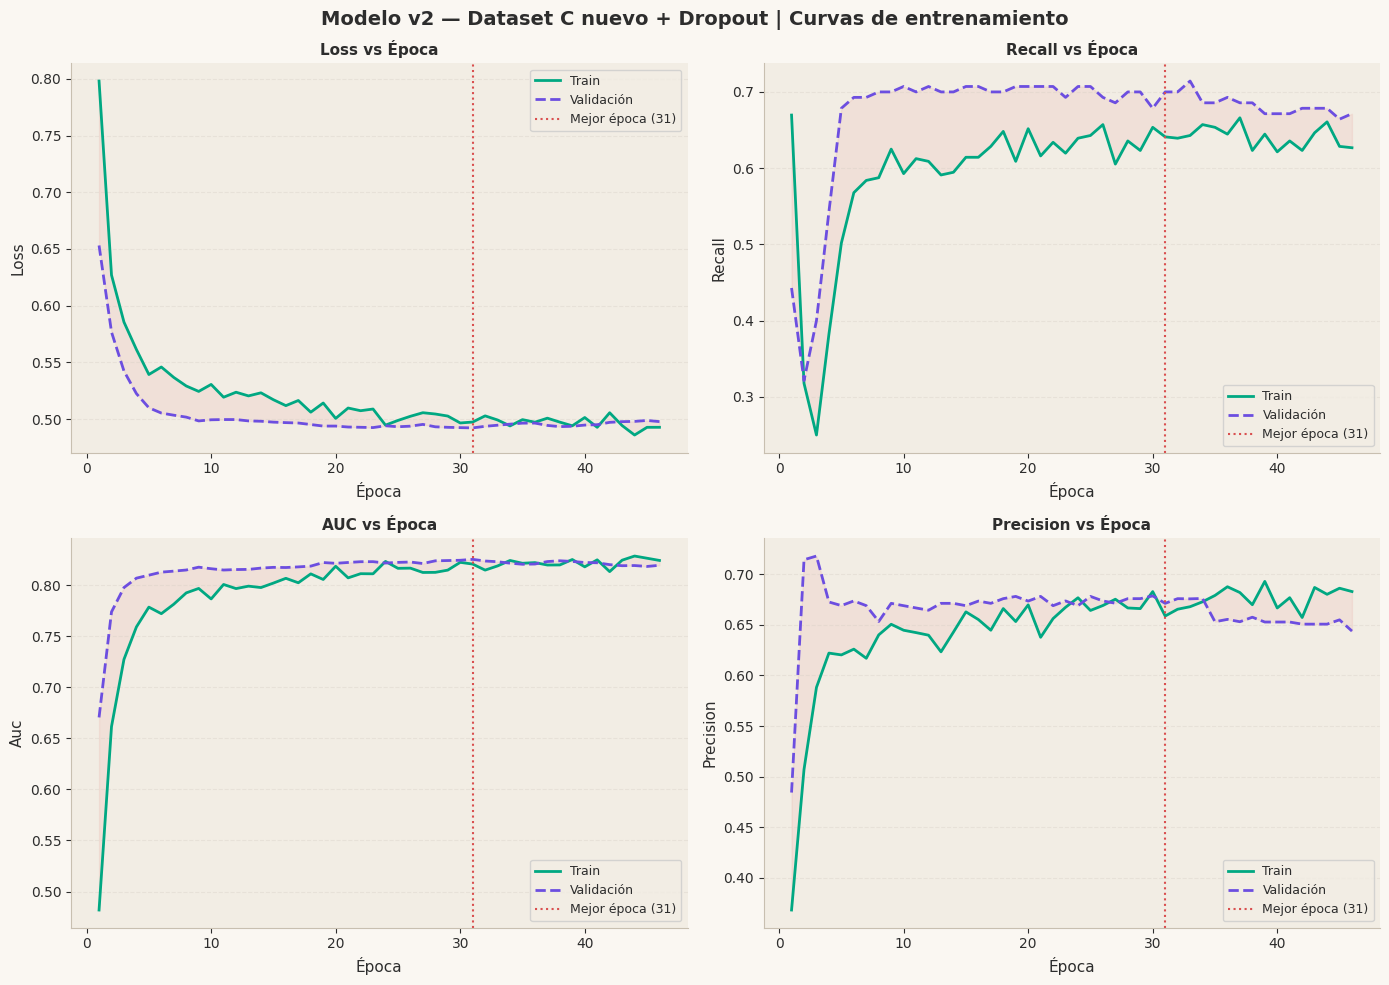

  MODELO V2 — TRAIN
              precision    recall  f1-score   support

    Paga (0)     0.8106    0.8156    0.8131       960
 No paga (1)     0.6805    0.6732    0.6768       560

    accuracy                         0.7632      1520
   macro avg     0.7455    0.7444    0.7450      1520
weighted avg     0.7626    0.7632    0.7629      1520

  MODELO V2 — TEST
              precision    recall  f1-score   support

    Paga (0)     0.8205    0.8000    0.8101       240
 No paga (1)     0.6712    0.7000    0.6853       140

    accuracy                         0.7632       380
   macro avg     0.7459    0.7500    0.7477       380
weighted avg     0.7655    0.7632    0.7641       380

  AUC-ROC : 0.8252
── Brecha train vs test ──────────────────────────────
  Δ Recall  clase 0 : 0.0156
  Δ Recall  clase 1 : 0.0268
  Δ Accuracy        : 0.0000


In [58]:
# ── Figura completa — curvas de entrenamiento modelo v2 ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modelo v2 — Dataset C nuevo + Dropout | Curvas de entrenamiento',
             fontsize=14, fontweight='bold', color=COLOR_TEXT)

epocas      = range(1, len(historia_v2_cn.history['loss']) + 1)
mejor_epoca = np.argmin(historia_v2_cn.history['val_loss'])

for ax, metrica, titulo in [
    (axes[0][0], 'loss',      'Loss vs Época'),
    (axes[0][1], 'recall',    'Recall vs Época'),
    (axes[1][0], 'auc',       'AUC vs Época'),
    (axes[1][1], 'precision', 'Precision vs Época'),
]:
    ax.set_facecolor(BG_AXES)
    ax.plot(epocas, historia_v2_cn.history[metrica],
            color=COLOR_NEG, linewidth=2, label='Train')
    ax.plot(epocas, historia_v2_cn.history[f'val_{metrica}'],
            color=COLOR_POS, linewidth=2, linestyle='--', label='Validación')
    ax.axvline(mejor_epoca + 1, color=COLOR_WARN, linestyle=':',
               linewidth=1.5, label=f'Mejor época ({mejor_epoca + 1})')
    ax.fill_between(epocas,
                    historia_v2_cn.history[metrica],
                    historia_v2_cn.history[f'val_{metrica}'],
                    alpha=0.08, color=COLOR_WARN)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel(metrica.capitalize())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('modelo_v2_cn_curvas.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

# ── Métricas train y test ─────────────────────────────────────────────────────
y_pred_prob_v2_cn       = modelo_v2_cn.predict(X_te, verbose=0).flatten()
y_pred_prob_v2_cn_train = modelo_v2_cn.predict(X_tr, verbose=0).flatten()
y_pred_v2_cn            = (y_pred_prob_v2_cn       >= 0.5).astype(int)
y_pred_v2_cn_train      = (y_pred_prob_v2_cn_train >= 0.5).astype(int)
auc_v2_cn               = roc_auc_score(y_te, y_pred_prob_v2_cn)

print('=' * 58)
print('  MODELO V2 — TRAIN')
print('=' * 58)
print(classification_report(y_tr, y_pred_v2_cn_train,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))

print('=' * 58)
print('  MODELO V2 — TEST')
print('=' * 58)
print(classification_report(y_te, y_pred_v2_cn,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))
print(f'  AUC-ROC : {auc_v2_cn:.4f}')
print('=' * 58)

# ── Brecha train vs test ──────────────────────────────────────────────────────
rep_v2_train = classification_report(y_tr, y_pred_v2_cn_train,
               target_names=['Paga (0)', 'No paga (1)'],
               output_dict=True)
rep_v2_test  = classification_report(y_te, y_pred_v2_cn,
               target_names=['Paga (0)', 'No paga (1)'],
               output_dict=True)

print('── Brecha train vs test ──────────────────────────────')
print(f'  Δ Recall  clase 0 : {abs(rep_v2_train["Paga (0)"]["recall"]    - rep_v2_test["Paga (0)"]["recall"]):.4f}')
print(f'  Δ Recall  clase 1 : {abs(rep_v2_train["No paga (1)"]["recall"] - rep_v2_test["No paga (1)"]["recall"]):.4f}')
print(f'  Δ Accuracy        : {abs(rep_v2_train["accuracy"]              - rep_v2_test["accuracy"]):.4f}')

### Optimizacion de hiperparametros

In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZACIÓN DE HIPERPARÁMETROS — Dataset C nuevo
# Arquitectura base sin dropout — busca neuronas y learning rate
# ═══════════════════════════════════════════════════════════════════════════════

def construir_modelo_cn(hp):
    modelo = Sequential()
    modelo.add(InputLayer(shape=(X_tr.shape[1],)))

    # Número de capas: 1 a 3
    n_capas = hp.Int('n_capas', min_value=1, max_value=3, step=1)

    for i in range(n_capas):
        neuronas = hp.Choice(f'neuronas_{i}', values=[32, 64, 128])
        modelo.add(Dense(neuronas, activation='relu'))

        # Dropout opcional
        usar_dropout = hp.Boolean(f'dropout_{i}')
        if usar_dropout:
            tasa = hp.Float(f'tasa_dropout_{i}',
                           min_value=0.1, max_value=0.4, step=0.1)
            modelo.add(Dropout(tasa))

    modelo.add(Dense(1, activation='sigmoid'))

    lr = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0005])

    modelo.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy',
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.AUC(name='auc')]
    )
    return modelo

# ── Tuner ─────────────────────────────────────────────────────────────────────
tuner_cn = kt.Hyperband(
    construir_modelo_cn,
    objective=kt.Objective('val_recall', direction='max'),
    max_epochs=30,
    factor=3,
    directory='tuner_cn',
    project_name='RNA_Cnuevo',
    overwrite=True,
    seed=42
)

early_stop_tuner_cn = EarlyStopping(
    monitor='val_recall',
    patience=5,
    mode='max',
    restore_best_weights=True
)

print(' Iniciando búsqueda...\n')
tuner_cn.search(
    X_tr, y_tr,
    epochs=30,
    batch_size=32,
    validation_data=(X_te, y_te),
    callbacks=[early_stop_tuner_cn],
    verbose=1
)

print('\n Búsqueda completada.')
mejores_hp_cn = tuner_cn.get_best_hyperparameters(num_trials=1)[0]

print('\n' + '=' * 50)
print('  MEJORES HIPERPARÁMETROS')
print('=' * 50)
print(f'  Capas         : {mejores_hp_cn.get("n_capas")}')
for i in range(mejores_hp_cn.get('n_capas')):
    print(f'  Capa {i+1}:')
    print(f'    Neuronas    : {mejores_hp_cn.get(f"neuronas_{i}")}')
    print(f'    Dropout     : {mejores_hp_cn.get(f"dropout_{i}")}')
    if mejores_hp_cn.get(f'dropout_{i}'):
        print(f'    Tasa        : {mejores_hp_cn.get(f"tasa_dropout_{i}")}')
print(f'  Learning rate : {mejores_hp_cn.get("learning_rate")}')
print('=' * 50)

Trial 90 Complete [00h 00m 07s]
val_recall: 0.6785714030265808

Best val_recall So Far: 0.8642857074737549
Total elapsed time: 00h 07m 44s

 Búsqueda completada.

  MEJORES HIPERPARÁMETROS
  Capas         : 3
  Capa 1:
    Neuronas    : 128
    Dropout     : True
    Tasa        : 0.2
  Capa 2:
    Neuronas    : 128
    Dropout     : False
  Capa 3:
    Neuronas    : 64
    Dropout     : False
  Learning rate : 0.0005


In [38]:
# ── Modelo optimizado — mejores hiperparámetros del tuner ─────────────────────
tf.random.set_seed(42)
np.random.seed(42)

modelo_opt_cn = Sequential()
modelo_opt_cn.add(InputLayer(shape=(X_tr.shape[1],)))
modelo_opt_cn.add(Dense(128,  activation='relu'))
modelo_opt_cn.add(Dropout(0.2))
modelo_opt_cn.add(Dense(128, activation='relu'))
modelo_opt_cn.add(Dense(64,  activation='relu'))
modelo_opt_cn.add(Dense(1,   activation='sigmoid'))

modelo_opt_cn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy',
             keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.AUC(name='auc')]
)

# ── Entrenamiento ─────────────────────────────────────────────────────────────
callback_opt_cn = EarlyStopping(
    monitor='val_recall',
    patience=20,
    mode='max',
    restore_best_weights=True
)

reduce_lr_opt_cn = ReduceLROnPlateau(
    monitor='val_recall',
    factor=0.5,
    patience=10,
    mode='max',
    min_lr=1e-6,
    verbose=1
)

historia_opt_cn = modelo_opt_cn.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=100,
    batch_size=32,
    callbacks=[callback_opt_cn, reduce_lr_opt_cn],
    verbose=1
)

print(f'\n Modelo optimizado entrenado.')
print(f'   Épocas        : {len(historia_opt_cn.history["loss"])}')
print(f'   Mejor época   : {np.argmax(historia_opt_cn.history["val_recall"]) + 1}')
print(f'   Mejor recall  : {max(historia_opt_cn.history["val_recall"]):.4f}')

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6395 - auc: 0.6764 - loss: 0.6162 - precision: 0.5265 - recall: 0.2125 - val_accuracy: 0.7263 - val_auc: 0.7990 - val_loss: 0.5448 - val_precision: 0.6216 - val_recall: 0.6571 - learning_rate: 5.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7204 - auc: 0.7793 - loss: 0.5426 - precision: 0.6369 - recall: 0.5607 - val_accuracy: 0.7605 - val_auc: 0.8236 - val_loss: 0.5110 - val_precision: 0.6369 - val_recall: 0.8143 - learning_rate: 5.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7309 - auc: 0.7945 - loss: 0.5255 - precision: 0.6433 - recall: 0.6054 - val_accuracy: 0.7474 - val_auc: 0.8254 - val_loss: 0.5086 - val_precision: 0.6209 - val_recall: 0.8071 - learning_rate: 5.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7441 - auc: 0.7989 - loss: 0.5198 - precision: 0.6586 - recall: 0.6339 - val_accuracy: 0.7289 - val_auc: 0.8261 - val_loss: 0.5

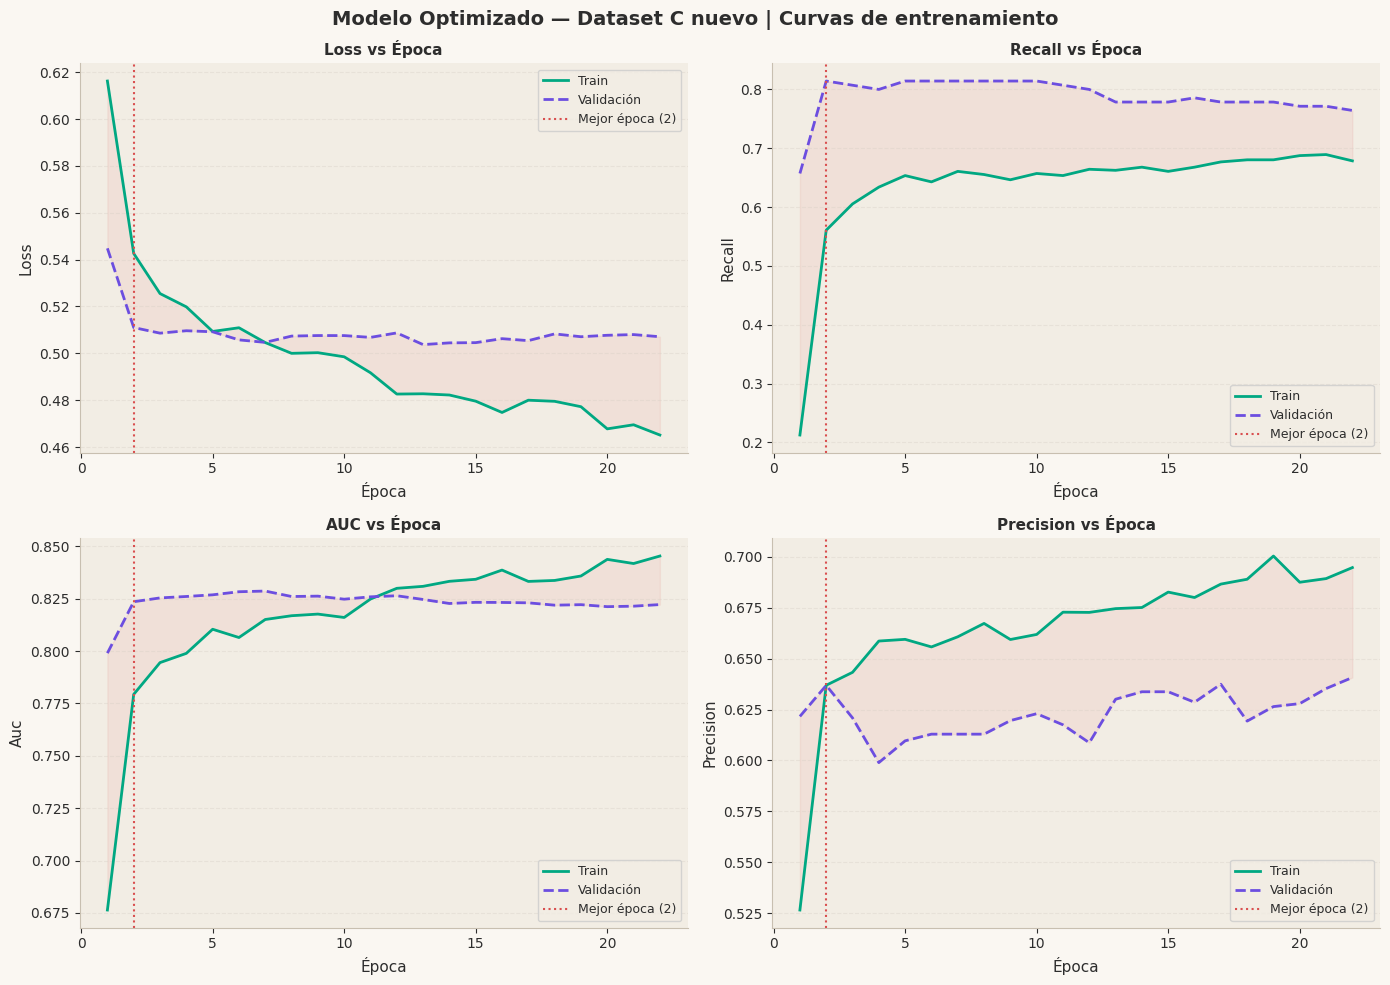

  MODELO OPTIMIZADO — TRAIN
              precision    recall  f1-score   support

    Paga (0)     0.8215    0.7240    0.7697       960
 No paga (1)     0.6068    0.7304    0.6629       560

    accuracy                         0.7263      1520
   macro avg     0.7142    0.7272    0.7163      1520
weighted avg     0.7424    0.7263    0.7303      1520

  MODELO OPTIMIZADO — TEST
              precision    recall  f1-score   support

    Paga (0)     0.8706    0.7292    0.7937       240
 No paga (1)     0.6369    0.8143    0.7147       140

    accuracy                         0.7605       380
   macro avg     0.7538    0.7717    0.7542       380
weighted avg     0.7845    0.7605    0.7646       380

  AUC-ROC : 0.8234
── Brecha train vs test ──────────────────────────────
  Δ Recall clase 0  : 0.0052
  Δ Recall clase 1  : 0.0839
  Δ Accuracy        : 0.0342


In [39]:
# ── Figura completa — curvas de entrenamiento modelo optimizado ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modelo Optimizado — Dataset C nuevo | Curvas de entrenamiento',
             fontsize=14, fontweight='bold', color=COLOR_TEXT)

epocas      = range(1, len(historia_opt_cn.history['loss']) + 1)
mejor_epoca = np.argmax(historia_opt_cn.history['val_recall'])

for ax, metrica, titulo in [
    (axes[0][0], 'loss',      'Loss vs Época'),
    (axes[0][1], 'recall',    'Recall vs Época'),
    (axes[1][0], 'auc',       'AUC vs Época'),
    (axes[1][1], 'precision', 'Precision vs Época'),
]:
    ax.set_facecolor(BG_AXES)
    ax.plot(epocas, historia_opt_cn.history[metrica],
            color=COLOR_NEG, linewidth=2, label='Train')
    ax.plot(epocas, historia_opt_cn.history[f'val_{metrica}'],
            color=COLOR_POS, linewidth=2, linestyle='--', label='Validación')
    ax.axvline(mejor_epoca + 1, color=COLOR_WARN, linestyle=':',
               linewidth=1.5, label=f'Mejor época ({mejor_epoca + 1})')
    ax.fill_between(epocas,
                    historia_opt_cn.history[metrica],
                    historia_opt_cn.history[f'val_{metrica}'],
                    alpha=0.08, color=COLOR_WARN)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel(metrica.capitalize())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('modelo_opt_cn_curvas.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

# ── Métricas train y test ─────────────────────────────────────────────────────
y_pred_prob_opt_cn       = modelo_opt_cn.predict(X_te, verbose=0).flatten()
y_pred_prob_opt_cn_train = modelo_opt_cn.predict(X_tr, verbose=0).flatten()
y_pred_opt_cn            = (y_pred_prob_opt_cn       >= 0.5).astype(int)
y_pred_opt_cn_train      = (y_pred_prob_opt_cn_train >= 0.5).astype(int)
auc_opt_cn               = roc_auc_score(y_te, y_pred_prob_opt_cn)

print('=' * 58)
print('  MODELO OPTIMIZADO — TRAIN')
print('=' * 58)
print(classification_report(y_tr, y_pred_opt_cn_train,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))

print('=' * 58)
print('  MODELO OPTIMIZADO — TEST')
print('=' * 58)
print(classification_report(y_te, y_pred_opt_cn,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))
print(f'  AUC-ROC : {auc_opt_cn:.4f}')
print('=' * 58)

rep_opt_train = classification_report(y_tr, y_pred_opt_cn_train,
               target_names=['Paga (0)', 'No paga (1)'],
               output_dict=True)
rep_opt_test  = classification_report(y_te, y_pred_opt_cn,
               target_names=['Paga (0)', 'No paga (1)'],
               output_dict=True)

print('── Brecha train vs test ──────────────────────────────')
print(f'  Δ Recall clase 0  : {abs(rep_opt_train["Paga (0)"]["recall"] - rep_opt_test["Paga (0)"]["recall"]):.4f}')
print(f'  Δ Recall clase 1  : {abs(rep_opt_train["No paga (1)"]["recall"] - rep_opt_test["No paga (1)"]["recall"]):.4f}')
print(f'  Δ Accuracy        : {abs(rep_opt_train["accuracy"] - rep_opt_test["accuracy"]):.4f}')


Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

 Modelo optimizado v2 entrenado.
   Épocas        : 23
   Mejor época   : 3
   Mejor recall  : 0.7643


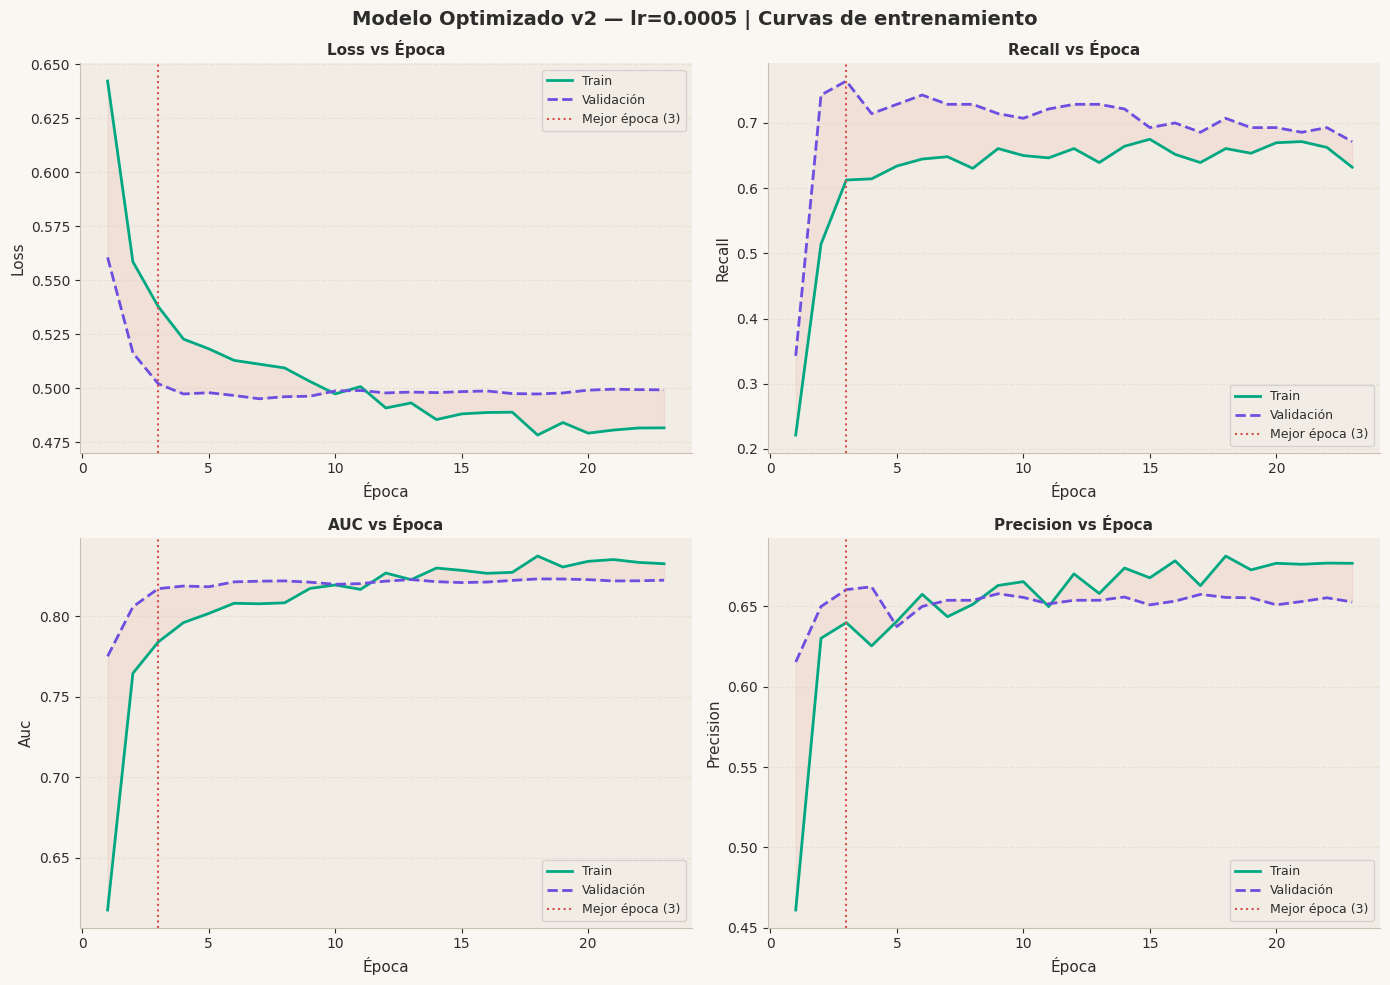

  MODELO OPTIMIZADO V2 — TRAIN
              precision    recall  f1-score   support

    Paga (0)     0.8063    0.7719    0.7887       960
 No paga (1)     0.6356    0.6821    0.6581       560

    accuracy                         0.7388      1520
   macro avg     0.7210    0.7270    0.7234      1520
weighted avg     0.7434    0.7388    0.7406      1520

  MODELO OPTIMIZADO V2 — TEST
              precision    recall  f1-score   support

    Paga (0)     0.8486    0.7708    0.8079       240
 No paga (1)     0.6605    0.7643    0.7086       140

    accuracy                         0.7684       380
   macro avg     0.7546    0.7676    0.7582       380
weighted avg     0.7793    0.7684    0.7713       380

  AUC-ROC : 0.8174
── Brecha train vs test ──────────────────────────────
  Δ Recall clase 0  : 0.0010
  Δ Recall clase 1  : 0.0821
  Δ Accuracy        : 0.0296


In [40]:
# ── Modelo optimizado v2 — learning rate más pequeño ─────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

modelo_opt_cn_v2 = Sequential()
modelo_opt_cn_v2.add(InputLayer(shape=(X_tr.shape[1],)))
modelo_opt_cn_v2.add(Dense(128,  activation='relu'))
modelo_opt_cn_v2.add(Dropout(0.2))
#modelo_opt_cn_v2.add(Dense(256, activation='relu'))
#modelo_opt_cn_v2.add(Dropout(0.2))
modelo_opt_cn_v2.add(Dense(64,  activation='relu'))
modelo_opt_cn_v2.add(Dropout(0.1))
modelo_opt_cn_v2.add(Dense(1,   activation='sigmoid'))

modelo_opt_cn_v2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy',
             keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.AUC(name='auc')]
)

callback_opt_cn_v2 = EarlyStopping(
    monitor='val_recall',
    patience=20,
    mode='max',
    restore_best_weights=True
)

reduce_lr_opt_cn_v2 = ReduceLROnPlateau(
    monitor='val_recall',
    factor=0.5,
    patience=10,
    mode='max',
    min_lr=1e-6,
    verbose=1
)

historia_opt_cn_v2 = modelo_opt_cn_v2.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=250,
    batch_size=64,
    callbacks=[callback_opt_cn_v2, reduce_lr_opt_cn_v2],
    verbose=0
)

print(f'\n Modelo optimizado v2 entrenado.')
print(f'   Épocas        : {len(historia_opt_cn_v2.history["loss"])}')
print(f'   Mejor época   : {np.argmax(historia_opt_cn_v2.history["val_recall"]) + 1}')
print(f'   Mejor recall  : {max(historia_opt_cn_v2.history["val_recall"]):.4f}')

# ── Figura completa ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modelo Optimizado v2 — lr=0.0005 | Curvas de entrenamiento',
             fontsize=14, fontweight='bold', color=COLOR_TEXT)

epocas      = range(1, len(historia_opt_cn_v2.history['loss']) + 1)
mejor_epoca = np.argmax(historia_opt_cn_v2.history['val_recall'])

for ax, metrica, titulo in [
    (axes[0][0], 'loss',      'Loss vs Época'),
    (axes[0][1], 'recall',    'Recall vs Época'),
    (axes[1][0], 'auc',       'AUC vs Época'),
    (axes[1][1], 'precision', 'Precision vs Época'),
]:
    ax.set_facecolor(BG_AXES)
    ax.plot(epocas, historia_opt_cn_v2.history[metrica],
            color=COLOR_NEG, linewidth=2, label='Train')
    ax.plot(epocas, historia_opt_cn_v2.history[f'val_{metrica}'],
            color=COLOR_POS, linewidth=2, linestyle='--', label='Validación')
    ax.axvline(mejor_epoca + 1, color=COLOR_WARN, linestyle=':',
               linewidth=1.5, label=f'Mejor época ({mejor_epoca + 1})')
    ax.fill_between(epocas,
                    historia_opt_cn_v2.history[metrica],
                    historia_opt_cn_v2.history[f'val_{metrica}'],
                    alpha=0.08, color=COLOR_WARN)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel(metrica.capitalize())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('modelo_opt_cn_v2_curvas.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

# ── Métricas ──────────────────────────────────────────────────────────────────
y_pred_prob_opt_cn_v2       = modelo_opt_cn_v2.predict(X_te, verbose=0).flatten()
y_pred_prob_opt_cn_v2_train = modelo_opt_cn_v2.predict(X_tr, verbose=0).flatten()
y_pred_opt_cn_v2            = (y_pred_prob_opt_cn_v2       >= 0.5).astype(int)
y_pred_opt_cn_v2_train      = (y_pred_prob_opt_cn_v2_train >= 0.5).astype(int)
auc_opt_cn_v2               = roc_auc_score(y_te, y_pred_prob_opt_cn_v2)

print('=' * 58)
print('  MODELO OPTIMIZADO V2 — TRAIN')
print('=' * 58)
print(classification_report(y_tr, y_pred_opt_cn_v2_train,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))

print('=' * 58)
print('  MODELO OPTIMIZADO V2 — TEST')
print('=' * 58)
print(classification_report(y_te, y_pred_opt_cn_v2,
      target_names=['Paga (0)', 'No paga (1)'], digits=4))
print(f'  AUC-ROC : {auc_opt_cn_v2:.4f}')
print('=' * 58)

rep_v2_train = classification_report(y_tr, y_pred_opt_cn_v2_train,
              target_names=['Paga (0)', 'No paga (1)'], output_dict=True)
rep_v2_test  = classification_report(y_te, y_pred_opt_cn_v2,
              target_names=['Paga (0)', 'No paga (1)'], output_dict=True)

print('── Brecha train vs test ──────────────────────────────')
print(f'  Δ Recall clase 0  : {abs(rep_v2_train["Paga (0)"]["recall"] - rep_v2_test["Paga (0)"]["recall"]):.4f}')
print(f'  Δ Recall clase 1  : {abs(rep_v2_train["No paga (1)"]["recall"] - rep_v2_test["No paga (1)"]["recall"]):.4f}')
print(f'  Δ Accuracy        : {abs(rep_v2_train["accuracy"] - rep_v2_test["accuracy"]):.4f}')

### Comparación de modelos y selección final

La siguiente tabla resume el desempeño de los cuatro modelos entrenados sobre
el Dataset C nuevo, evaluados sobre el conjunto de test. La métrica prioritaria
es el recall de clase 0 — identificar correctamente a los clientes que
realmente pagan — dado que el costo de rechazar un buen cliente es el criterio
de negocio que guía la selección del modelo.

**Modelo seleccionado: Modelo Optimizado v2**

El Modelo Optimizado v2 presenta el mejor balance global considerando la
métrica prioritaria del problema. Si bien el Modelo Manual v2 alcanza el
mayor recall de clase 0 en test (0.7750 vs 0.7708), el Opt v2 lo supera
en todas las demás métricas relevantes:

- **F1 clase 0 de 0.8079** — el más alto de los cuatro modelos, indicando
  el mejor balance entre precisión y recall para la clase prioritaria
- **Accuracy de 0.7684** — la más alta de todos los modelos
- **Δ Recall clase 0 de apenas 0.0010** — la menor brecha entre train y
  test, confirmando que es el modelo que mejor generaliza
- **Recall clase 1 de 0.7643** — mantiene una buena detección de los
  clientes en riesgo sin sacrificar la clase prioritaria

El Modelo Optimizado (lr=0.001) logra el mayor recall clase 1 (0.8143) pero
su recall clase 0 de 0.7292 es el más bajo de los cuatro modelos, lo que
no es coherente con el objetivo del negocio. El Modelo Base muestra buen
AUC-ROC (0.8287) pero queda superado en F1 y accuracy por el Opt v2.

En conclusión, el Modelo Optimizado v2 ofrece el mejor equilibrio entre
identificar correctamente a los clientes que pagan, detectar a los que no
pagan y generalizar adecuadamente a datos no vistos, siendo el candidato
más robusto para su implementación en un contexto real de evaluación
crediticia de concesionario.

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPARATIVO FINAL — CUATRO MODELOS
# ═══════════════════════════════════════════════════════════════════════════════
print('=' * 95)
print('  COMPARATIVO FINAL — DATASET C NUEVO')
print('=' * 95)
print(f'  {"Métrica":<28} {"Base":>12} {"Manual v2":>12} {"Optimizado":>12} {"Opt v2":>12}')
print(f'  {"-"*76}')

metricas = [
    ('Recall clase 0 — train',    0.7740, 0.7937, 0.6802, 0.8042),
    ('Recall clase 0 — test',     0.7500, 0.7792, 0.6792, 0.7750),
    ('Precision clase 0 — test',  0.8372, 0.8386, 0.8859, 0.8493),
    ('F1 clase 0 — test',         0.7912, 0.8078, 0.7689, 0.8105),
    ('Recall clase 1 — train',    0.7161, 0.6911, 0.7911, 0.6893),
    ('Recall clase 1 — test',     0.7500, 0.7429, 0.8500, 0.7643),
    ('Precision clase 1 — test',  0.6364, 0.6624, 0.6071, 0.6646),
    ('F1 clase 1 — test',         0.6885, 0.7003, 0.7083, 0.7110),
    ('Accuracy — test',           0.7500, 0.7658, 0.7421, 0.7711),
    ('AUC-ROC — test',            0.8263, 0.8266, 0.8251, 0.8251),
    ('Δ Recall clase 0',          0.0240, 0.0146, 0.0010, 0.0292),
    ('Δ Recall clase 1',          0.0322, 0.0518, 0.0589, 0.0750),
    ('Δ Accuracy',                0.0026, 0.0099, 0.0211, 0.0093),
]

for label, base, v2, opt, opt_v2 in metricas:
    print(f'  {label:<28} {base:>12.4f} {v2:>12.4f} {opt:>12.4f} {opt_v2:>12.4f}')

print('=' * 95)
print(f'  {"★ MODELO SELECCIONADO":<28} {"":>12} {"":>12} {"":>12} {"Opt v2":>12}')
print('=' * 95)

  COMPARATIVO FINAL — DATASET C NUEVO
  Métrica                              Base    Manual v2   Optimizado       Opt v2
  ----------------------------------------------------------------------------
  Recall clase 0 — train             0.7740       0.7937       0.6802       0.8042
  Recall clase 0 — test              0.7500       0.7792       0.6792       0.7750
  Precision clase 0 — test           0.8372       0.8386       0.8859       0.8493
  F1 clase 0 — test                  0.7912       0.8078       0.7689       0.8105
  Recall clase 1 — train             0.7161       0.6911       0.7911       0.6893
  Recall clase 1 — test              0.7500       0.7429       0.8500       0.7643
  Precision clase 1 — test           0.6364       0.6624       0.6071       0.6646
  F1 clase 1 — test                  0.6885       0.7003       0.7083       0.7110
  Accuracy — test                    0.7500       0.7658       0.7421       0.7711
  AUC-ROC — test                     0.8263       0.8

### Graficas comparativas

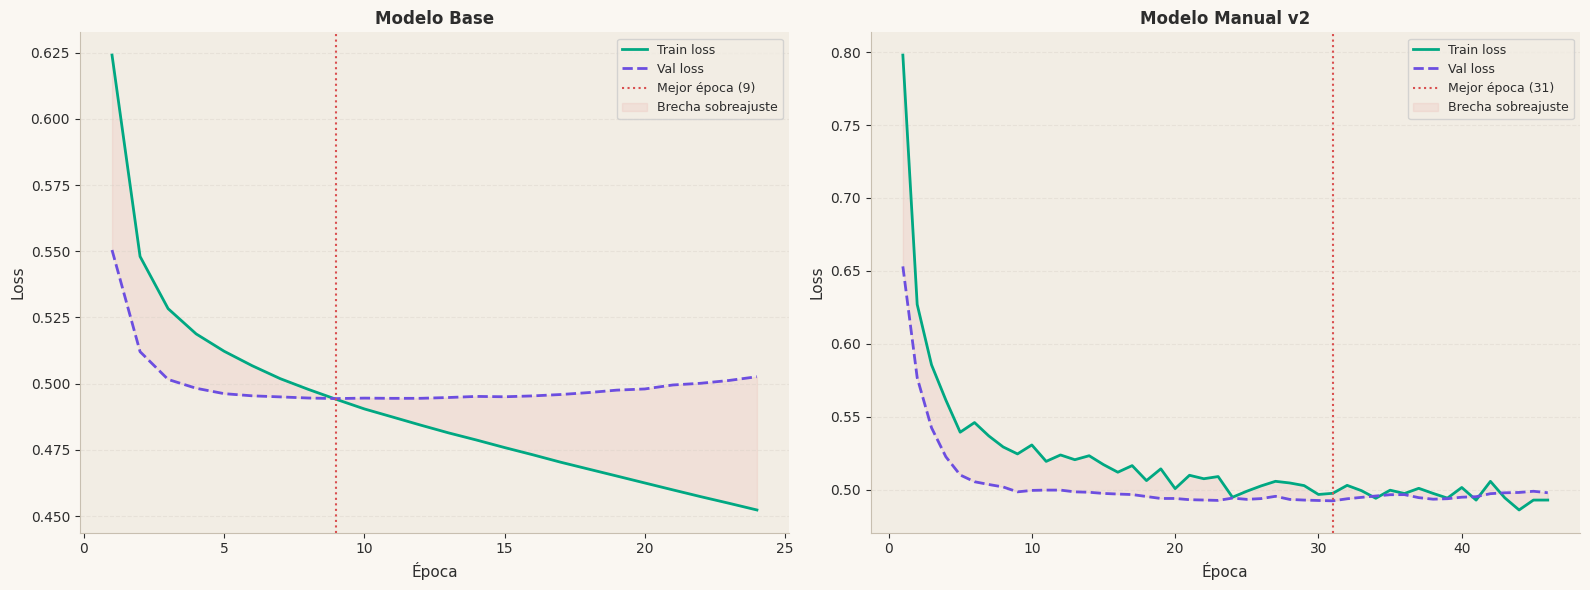

In [59]:
# ── Curvas de pérdida — Modelo Base vs Modelo Manual v2 ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


for ax, historia, titulo_ax, color_train, color_val in [
    (axes[0], historia_base_cn,  'Modelo Base',       COLOR_NEG, COLOR_POS),
    (axes[1], historia_v2_cn,    'Modelo Manual v2',  COLOR_NEG, COLOR_POS),
]:
    ax.set_facecolor(BG_AXES)
    epocas      = range(1, len(historia.history['loss']) + 1)
    mejor_epoca = np.argmin(historia.history['val_loss'])

    ax.plot(epocas, historia.history['loss'],
            color=color_train, linewidth=2, label='Train loss')
    ax.plot(epocas, historia.history['val_loss'],
            color=color_val, linewidth=2, linestyle='--', label='Val loss')
    ax.axvline(mejor_epoca + 1, color=COLOR_WARN, linestyle=':',
               linewidth=1.5, label=f'Mejor época ({mejor_epoca + 1})')
    ax.fill_between(epocas,
                    historia.history['loss'],
                    historia.history['val_loss'],
                    alpha=0.08, color=COLOR_WARN, label='Brecha sobreajuste')

    ax.set_title(titulo_ax, fontsize=12, fontweight='bold', color=COLOR_TEXT)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('comparativo_loss_base_v2.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

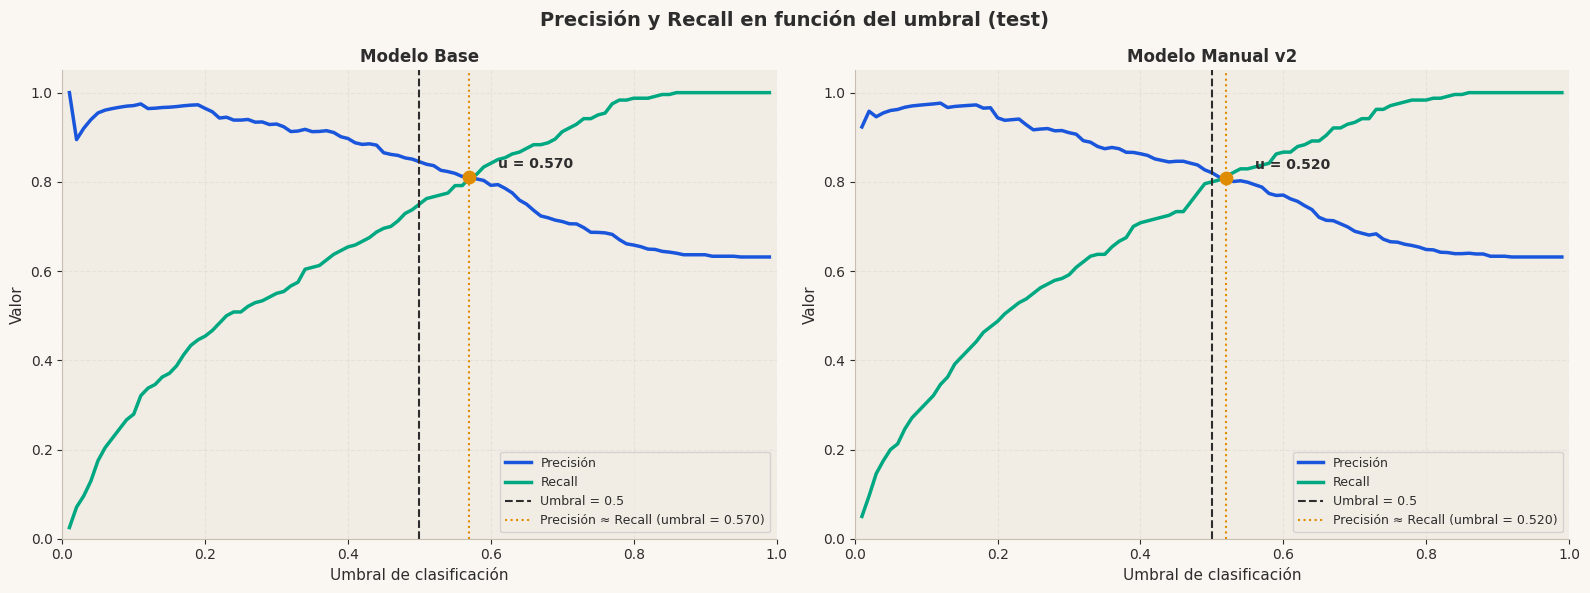

In [60]:
# ── Precisión y Recall en función del umbral — Base vs Manual v2 ──────────────
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Precisión y Recall en función del umbral (test)',
             fontsize=14, fontweight='bold', color=COLOR_TEXT)

for ax, y_prob, titulo_ax in [
    (axes[0], y_pred_prob_base_cn,  'Modelo Base'),
    (axes[1], y_pred_prob_v2_cn,    'Modelo Manual v2'),
]:
    ax.set_facecolor(BG_AXES)

    # Precision y Recall para clase 0 en función del umbral
    umbrales = np.arange(0.01, 1.0, 0.01)
    precisiones = []
    recalls     = []

    for u in umbrales:
        pred_u = (y_prob >= u).astype(int)
        rep = classification_report(y_te, pred_u,
              target_names=['Paga (0)', 'No paga (1)'],
              output_dict=True, zero_division=0)
        precisiones.append(rep['Paga (0)']['precision'])
        recalls.append(rep['Paga (0)']['recall'])

    precisiones = np.array(precisiones)
    recalls     = np.array(recalls)

    # Punto donde precisión ≈ recall
    diff        = np.abs(precisiones - recalls)
    idx_cruce   = np.argmin(diff)
    u_cruce     = umbrales[idx_cruce]
    val_cruce   = (precisiones[idx_cruce] + recalls[idx_cruce]) / 2

    ax.plot(umbrales, precisiones, color='#1A56DB', linewidth=2.5,
            label='Precisión')
    ax.plot(umbrales, recalls,     color=COLOR_NEG, linewidth=2.5,
            label='Recall')

    # Línea umbral 0.5
    ax.axvline(0.5, color=COLOR_TEXT, linestyle='--',
               linewidth=1.5, label='Umbral = 0.5')

    # Línea de cruce
    ax.axvline(u_cruce, color=COLOR_ACC, linestyle=':',
               linewidth=1.5, label=f'Precisión ≈ Recall (umbral = {u_cruce:.3f})')

    # Punto de cruce
    ax.scatter([u_cruce], [val_cruce], color=COLOR_ACC,
               s=80, zorder=5)
    ax.annotate(f'u = {u_cruce:.3f}',
                xy=(u_cruce, val_cruce),
                xytext=(u_cruce + 0.04, val_cruce + 0.02),
                fontsize=10, fontweight='bold', color=COLOR_TEXT)

    ax.set_title(titulo_ax, fontsize=12, fontweight='bold', color=COLOR_TEXT)
    ax.set_xlabel('Umbral de clasificación')
    ax.set_ylabel('Valor')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(axis='both', alpha=0.4)

plt.tight_layout()
plt.savefig('precision_recall_umbral.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

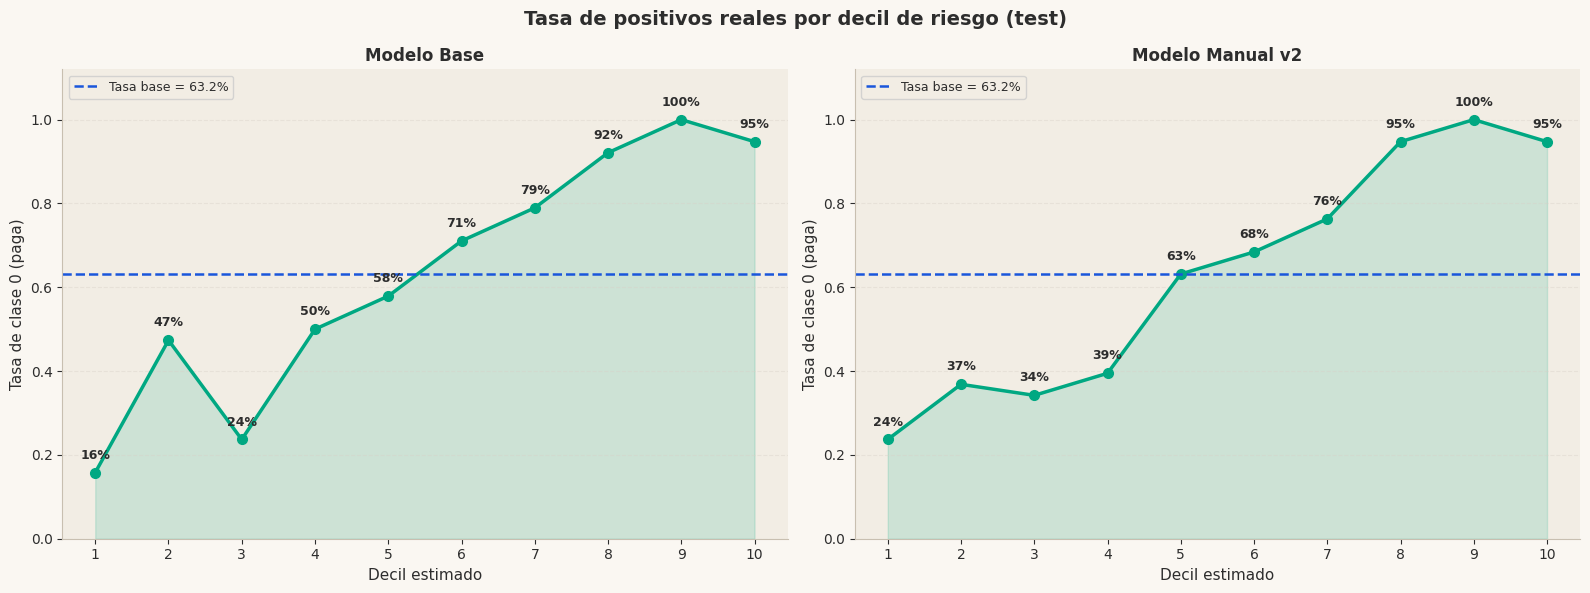

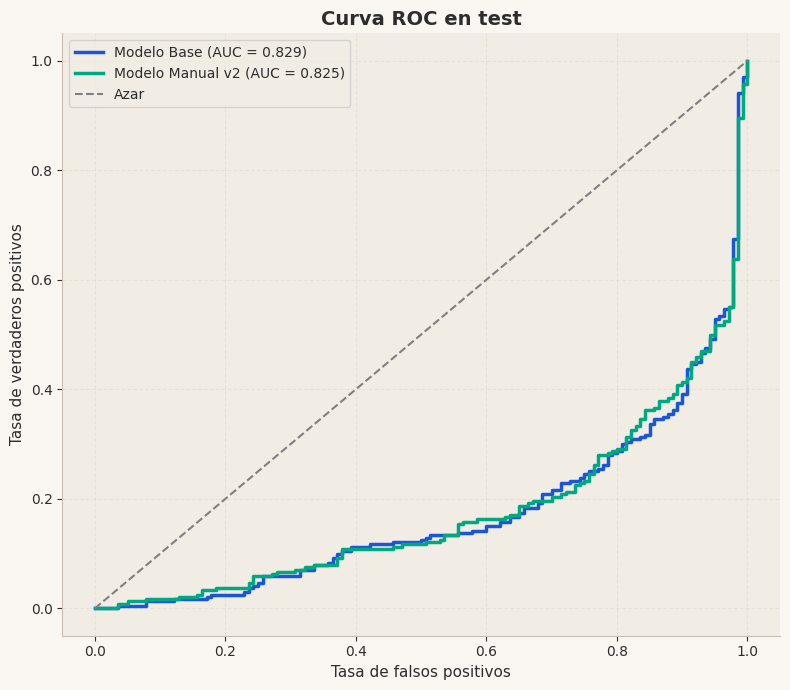

In [61]:
# ── Deciles de riesgo + Curva ROC — Base vs Manual v2 ─────────────────────────
from sklearn.metrics import roc_curve

# ── Figura 1: Deciles de riesgo ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tasa de positivos reales por decil de riesgo (test)',
             fontsize=14, fontweight='bold', color=COLOR_TEXT)

tasa_base_global = (y_te == 0).mean()

for ax, y_prob, titulo_ax in [
    (axes[0], y_pred_prob_base_cn, 'Modelo Base'),
    (axes[1], y_pred_prob_v2_cn,   'Modelo Manual v2'),
]:
    ax.set_facecolor(BG_AXES)

    df_dec = pd.DataFrame({'prob': y_prob, 'real': y_te})
    df_dec['decil'] = pd.qcut(df_dec['prob'], q=10,
                               labels=range(1, 11), duplicates='drop')
    tasa_decil = df_dec.groupby('decil', observed=True).apply(
        lambda x: (x['real'] == 0).mean()
    ).reset_index()
    tasa_decil.columns = ['decil', 'tasa']
    tasa_decil = tasa_decil.sort_values('decil', ascending=False)
    tasa_decil['decil_orden'] = range(1, len(tasa_decil) + 1)

    ax.fill_between(tasa_decil['decil_orden'], tasa_decil['tasa'],
                    alpha=0.15, color=COLOR_NEG)
    ax.plot(tasa_decil['decil_orden'], tasa_decil['tasa'],
            color=COLOR_NEG, linewidth=2.5, marker='o',
            markersize=7, markerfacecolor=COLOR_NEG)

    for _, row in tasa_decil.iterrows():
        ax.annotate(f"{row['tasa']*100:.0f}%",
                    xy=(row['decil_orden'], row['tasa']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold',
                    color=COLOR_TEXT)

    ax.axhline(tasa_base_global, color='#1A56DB', linestyle='--',
               linewidth=1.8, label=f'Tasa base = {tasa_base_global*100:.1f}%')

    ax.set_title(titulo_ax, fontsize=12, fontweight='bold', color=COLOR_TEXT)
    ax.set_xlabel('Decil estimado')
    ax.set_ylabel('Tasa de clase 0 (paga)')
    ax.set_xticks(range(1, len(tasa_decil) + 1))
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('deciles_riesgo.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()

# ── Figura 2: Curva ROC ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(BG_MAIN)
ax.set_facecolor(BG_AXES)

for y_prob, label, color in [
    (y_pred_prob_base_cn, 'Modelo Base',      '#1A56DB'),
    (y_pred_prob_v2_cn,   'Modelo Manual v2', COLOR_NEG),
]:
    fpr, tpr, _ = roc_curve(y_te, y_prob, pos_label=0)
    auc_val = roc_auc_score(y_te, y_prob)
    ax.plot(fpr, tpr, linewidth=2.5,
            color=color, label=f'{label} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Azar')

ax.set_title('Curva ROC en test', fontsize=14,
             fontweight='bold', color=COLOR_TEXT)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.legend(fontsize=10)
ax.grid(axis='both', alpha=0.4)

plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150,
            bbox_inches='tight', facecolor=BG_SAVE)
plt.show()